# lineitem - Experiment 4: Sketching Algorithm Comparison


In [2]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Configuration
LOG_DIR = './result'
OUTPUT_DIR = './exp4_output'


# ==========================================
# PLOTTING
# ==========================================
plt.style.use('../../logs/custom_plt_style.mplstyle')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## 1. Log File Parser

In [3]:
def parse_log_file(filepath):
    """Parse a single log file and extract all metrics including detailed I/O."""
    filename = os.path.basename(filepath)
    
    # Parse filename to extract experiment parameters
    exp_match = re.search(r'(Exp\d+\.?\d*)', filename)  # Support Exp3.1 format
    thr_match = re.search(r'Thr(\d+)', filename)
    mem_match = re.search(r'Mem(\d+)GB', filename)
    imb_match = re.search(r'Imbalance([\d.]+)', filename)
    
    if not (exp_match and thr_match and mem_match):
        return None
    
    result = {
        'experiment': exp_match.group(1),
        'threads': int(thr_match.group(1)),
        'memory_gb': int(mem_match.group(1)),
        'imbalance_factor': float(imb_match.group(1)) if imb_match else None,
        'filename': filename
    }
    
    # Parse metrics from log file
    with open(filepath, 'r') as f:
        content = f.read()
        
        # Find the [avg] line in Benchmark Results Summary
        avg_match = re.search(
            r'(\w+)\[avg\]\s+(\S+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)',
            content
        )
        
        if avg_match:
            result['run_size_mb'] = float(avg_match.group(2))
            result['num_runs'] = int(avg_match.group(3))
            result['gen_threads'] = int(avg_match.group(4))
            result['merge_threads'] = int(avg_match.group(5))
            result['total_time'] = float(avg_match.group(6))
            result['rungen_time'] = float(avg_match.group(7))
            result['merge_time'] = float(avg_match.group(8))
            result['entries'] = int(avg_match.group(9))
            result['throughput'] = float(avg_match.group(10))
            result['read_mb'] = float(avg_match.group(11))
            result['write_mb'] = float(avg_match.group(12))
        
        # Extract read amplification factor
        read_amp_match = re.search(r'Read amplification factor: ([\d.]+)x', content)
        if read_amp_match:
            result['read_amplification'] = float(read_amp_match.group(1))
        
        # Count merge passes
        merge_passes_match = re.search(r'Total merge passes: (\d+)', content)
        if merge_passes_match:
            result['merge_passes'] = int(merge_passes_match.group(1))
        else:
            result['merge_passes'] = 1
        
        # Extract partition imbalance - WEIGHTED average by partition size
        # Each merge operation has 5 columns: PAvg, PMax, Imbal, Slow, Fast
        # PAvg is at positions 0, 5, 10, 15 (0-indexed)
        # Imbal is at positions 2, 7, 12, 17 (0-indexed)
        merge_section = content.split('Merge Operations Summary')[-1]
        avg_line_match = re.search(r'\[avg\]\s+([\d.\s]+)', merge_section)
        if avg_line_match:
            # Extract all numbers from the [avg] line
            numbers_str = avg_line_match.group(1).strip()
            numbers = [float(n) for n in numbers_str.split()]
            
            # Extract partition sizes and imbalance values
            partition_sizes = []
            imbalances = []
            for i in range(0, len(numbers), 5):
                if i + 2 < len(numbers):
                    partition_sizes.append(numbers[i])      # M1PAvg, M2PAvg, M3PAvg, M4PAvg
                    imbalances.append(numbers[i + 2])       # M1Imbal, M2Imbal, M3Imbal, M4Imbal
            
            # Calculate weighted average: sum(PAvg * Imbal) / sum(PAvg)
            if partition_sizes and imbalances:
                weighted_sum = sum(p * i for p, i in zip(partition_sizes, imbalances))
                total_weight = sum(partition_sizes)
                result['partition_imbalance'] = weighted_sum / total_weight
        
        # Extract detailed I/O statistics from [avg] line
        io_section = content.split('Detailed I/O Statistics')[-1]
        io_avg_match = re.search(
            r'\[avg\]\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)(?:\s+([\d.]+)\s+([\d.]+))?(?:\s+([\d.]+)\s+([\d.]+))?',
            io_section
        )
        
        if io_avg_match:
            result['rg_read_mb'] = float(io_avg_match.group(1))
            result['rg_write_mb'] = float(io_avg_match.group(2))
            result['m1_read_mb'] = float(io_avg_match.group(3))
            result['m1_write_mb'] = float(io_avg_match.group(4))
            result['m2_read_mb'] = float(io_avg_match.group(5)) if io_avg_match.group(5) else 0.0
            result['m2_write_mb'] = float(io_avg_match.group(6)) if io_avg_match.group(6) else 0.0
            result['m3_read_mb'] = float(io_avg_match.group(7)) if io_avg_match.group(7) else 0.0
            result['m3_write_mb'] = float(io_avg_match.group(8)) if io_avg_match.group(8) else 0.0
            
            # Calculate total I/O
            result['total_io_mb'] = (result['rg_read_mb'] + result['rg_write_mb'] + 
                                     result['m1_read_mb'] + result['m1_write_mb'] +
                                     result['m2_read_mb'] + result['m2_write_mb'] +
                                     result['m3_read_mb'] + result['m3_write_mb'])
    
    return result if 'total_time' in result else None


def load_all_experiments(log_dir):
    """Load all log files and organize by experiment."""
    log_files = glob.glob(os.path.join(log_dir, '*.log'))
    
    all_data = []
    for filepath in log_files:
        parsed = parse_log_file(filepath)
        if parsed:
            all_data.append(parsed)
    
    df = pd.DataFrame(all_data)
    return df


# Load all data
df_all = load_all_experiments(LOG_DIR)
print(f"Loaded {len(df_all)} experiment results")
print(f"\nExperiments found: {sorted(df_all['experiment'].unique())}")

Loaded 51 experiment results

Experiments found: ['Exp1', 'Exp2', 'Exp3', 'Exp3.1', 'Exp4', 'Exp5']


In [4]:
def parse_exp1_subexp_log(filepath):
    """Parse Exp1.1 and Exp1.2 log files with RunGen/Merge thread counts."""
    filename = os.path.basename(filepath)

    # Parse filename: Exp1.1_RunGen40_Merge16_Mem2GB.log
    exp_match = re.search(r'(Exp\d+\.\d+)', filename)
    rungen_match = re.search(r'RunGen(\d+)', filename)
    merge_match = re.search(r'Merge(\d+)', filename)
    mem_match = re.search(r'Mem(\d+)GB', filename)

    if not (exp_match and rungen_match and merge_match and mem_match):
        return None

    result = {
        'experiment': exp_match.group(1),
        'rungen_threads': int(rungen_match.group(1)),
        'merge_threads': int(merge_match.group(1)),
        'memory_gb': int(mem_match.group(1)),
        'filename': filename
    }

    # Parse metrics from log file
    with open(filepath, 'r') as f:
        content = f.read()

        # Find the [avg] line in Benchmark Results Summary
        avg_match = re.search(
            r'(\w+)\[avg\]\s+(\S+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)',
            content
        )

        if avg_match:
            result['run_size_mb'] = float(avg_match.group(2))
            result['num_runs'] = int(avg_match.group(3))
            result['gen_threads'] = int(avg_match.group(4))
            result['merge_threads_actual'] = int(avg_match.group(5))
            result['total_time'] = float(avg_match.group(6))
            result['rungen_time'] = float(avg_match.group(7))
            result['merge_time'] = float(avg_match.group(8))
            result['entries'] = int(avg_match.group(9))
            result['throughput'] = float(avg_match.group(10))
            result['read_mb'] = float(avg_match.group(11))
            result['write_mb'] = float(avg_match.group(12))

        # Extract read amplification factor
        read_amp_match = re.search(r'Read amplification factor: ([\d.]+)x', content)
        if read_amp_match:
            result['read_amplification'] = float(read_amp_match.group(1))

        # Count merge passes
        merge_passes_match = re.search(r'Total merge passes: (\d+)', content)
        if merge_passes_match:
            result['merge_passes'] = int(merge_passes_match.group(1))

        # Extract detailed I/O statistics from [avg] line
        io_section = content.split('Detailed I/O Statistics')[-1]
        io_avg_match = re.search(
            r'\[avg\]\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)(?:\s+([\d.]+)\s+([\d.]+))?(?:\s+([\d.]+)\s+([\d.]+))?',
            io_section
        )

        if io_avg_match:
            result['rg_read_mb'] = float(io_avg_match.group(1))
            result['rg_write_mb'] = float(io_avg_match.group(2))
            result['m1_read_mb'] = float(io_avg_match.group(3))
            result['m1_write_mb'] = float(io_avg_match.group(4))
            result['m2_read_mb'] = float(io_avg_match.group(5)) if io_avg_match.group(5) else 0.0
            result['m2_write_mb'] = float(io_avg_match.group(6)) if io_avg_match.group(6) else 0.0
            result['m3_read_mb'] = float(io_avg_match.group(7)) if io_avg_match.group(7) else 0.0
            result['m3_write_mb'] = float(io_avg_match.group(8)) if io_avg_match.group(8) else 0.0

            # Calculate total I/O
            result['total_io_mb'] = (result['rg_read_mb'] + result['rg_write_mb'] +
                                     result['m1_read_mb'] + result['m1_write_mb'] +
                                     result['m2_read_mb'] + result['m2_write_mb'] +
                                     result['m3_read_mb'] + result['m3_write_mb'])

    return result if 'total_time' in result else None

In [5]:
# Load Exp1 data (KLL Sketch - baseline)
print("="*100)
print("EXP1: SCALABILITY TRAP (2GB RAM, Varying Threads) - KLL SKETCH")
print("="*100)
df_exp1 = df_all[df_all['experiment'] == 'Exp1'].sort_values('threads')
display_cols = ['threads', 'num_runs', 'total_time', 'rungen_time', 'merge_time', 
                'throughput', 'merge_passes', 'read_amplification', 'partition_imbalance']
print(df_exp1[display_cols].to_string(index=False))
if not df_exp1.empty:
    print(f"\nOptimal: {df_exp1.loc[df_exp1['total_time'].idxmin(), 'threads']:.0f} threads @ {df_exp1['total_time'].min():.1f}s")
    print(f"Worst: {df_exp1.loc[df_exp1['total_time'].idxmax(), 'threads']:.0f} threads @ {df_exp1['total_time'].max():.1f}s")

EXP1: SCALABILITY TRAP (2GB RAM, Varying Threads) - KLL SKETCH
 threads  num_runs  total_time  rungen_time  merge_time  throughput  merge_passes  read_amplification  partition_imbalance
       4       176     2692.66      2107.48      585.18        1.11             1                1.00                 1.02
       8       352     1557.55      1135.38      422.17        1.93             1                1.00                 1.05
      16       704      928.90       618.52      310.38        3.23             1                1.01                 1.10
      24      1056      757.50       490.92      266.58        3.96             1                1.02                 1.10
      32      1408      739.07       432.11      306.96        4.06             2                1.22                 1.19
      40      1760      719.29       372.39      346.90        4.17             3                1.43                 1.26
      44      1935      737.70       374.15      363.55        4.07         

In [6]:
# Load Exp4 data (Reservoir Sampling)
print("\n" + "="*100)
print("EXP4: SKETCHING ALGORITHM COMPARISON (2GB RAM, Varying Threads) - RESERVOIR SAMPLING")
print("="*100)
df_exp4 = df_all[df_all['experiment'] == 'Exp4'].sort_values('threads')
display_cols = ['threads', 'num_runs', 'total_time', 'rungen_time', 'merge_time', 
                'throughput', 'merge_passes', 'read_amplification', 'partition_imbalance']
print(df_exp4[display_cols].to_string(index=False))
if not df_exp4.empty:
    print(f"\nOptimal: {df_exp4.loc[df_exp4['total_time'].idxmin(), 'threads']:.0f} threads @ {df_exp4['total_time'].min():.1f}s")
    print(f"Worst: {df_exp4.loc[df_exp4['total_time'].idxmax(), 'threads']:.0f} threads @ {df_exp4['total_time'].max():.1f}s")


EXP4: SKETCHING ALGORITHM COMPARISON (2GB RAM, Varying Threads) - RESERVOIR SAMPLING
 threads  num_runs  total_time  rungen_time  merge_time  throughput  merge_passes  read_amplification  partition_imbalance
       4       176     2684.78      2069.20      615.57        1.12             1                1.00             1.230000
       8       352     1492.24      1063.82      428.42        2.01             1                1.00             1.320000
      16       704      959.58       585.52      374.06        3.13             1                1.01             1.780000
      24      1056      769.76       462.28      307.48        3.90             1                1.02             1.700000
      32      1408      754.69       406.45      348.24        3.98             2                1.22             1.950000
      40      1760      750.95       353.97      396.98        3.99             3                1.43             2.269655
      44      1935      766.36       351.69      414.

In [7]:
colors = {
    'total': '#1f77b4',
    'rungen': '#2ca02c', 
    'merge': '#d62728',
    'exp2': '#ff7f0e',
    'exp3': '#9467bd',
    'exp4': '#8c564b'
}

### Plot 4: Exp4 - KLL vs Reservoir Sampling Comparison

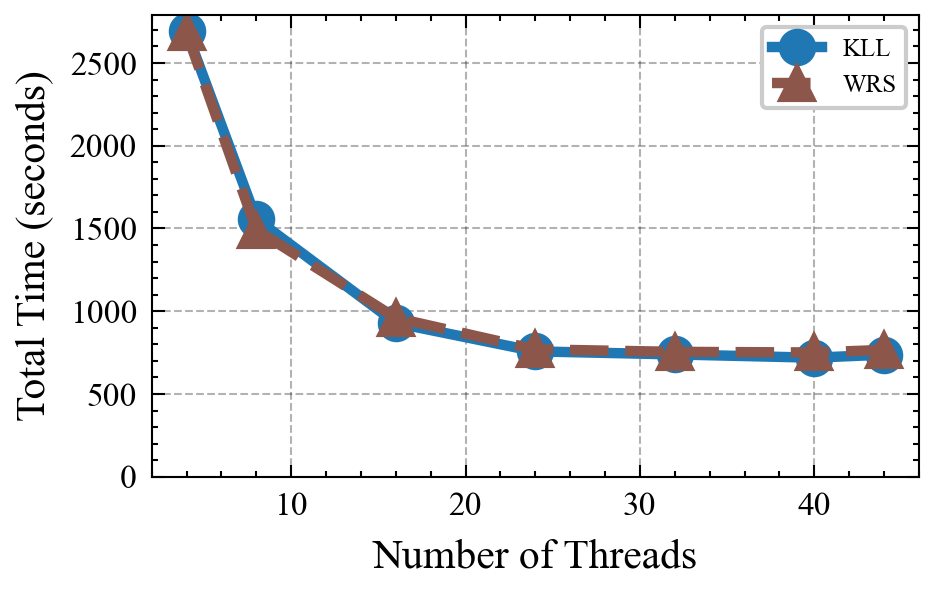

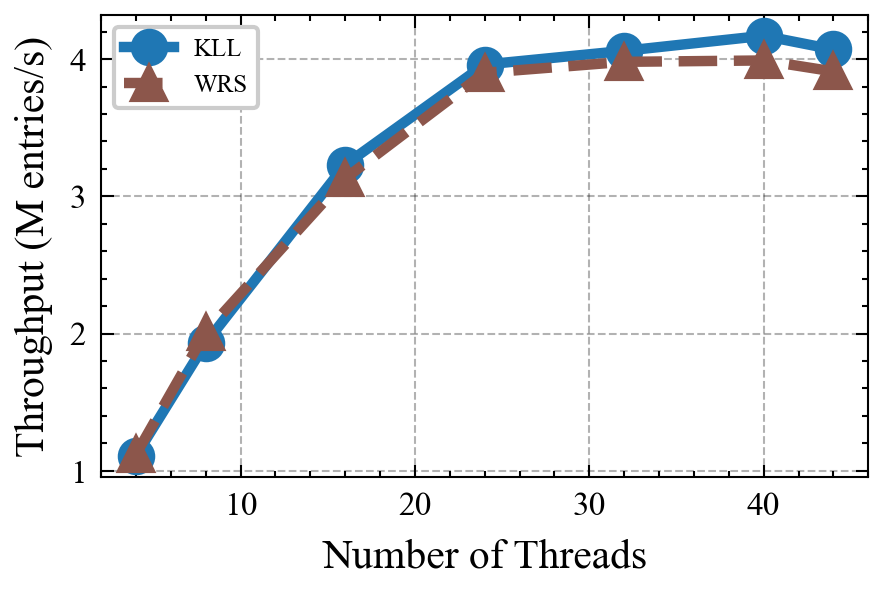


📊 Exp4 Insight: Reservoir Sampling is 1.5% slower than KLL on average.
 threads  total_time_kll  total_time_rs  time_diff_pct
       4         2692.66        2684.78      -0.292647
       8         1557.55        1492.24      -4.193124
      16          928.90         959.58       3.302831
      24          757.50         769.76       1.618482
      32          739.07         754.69       2.113467
      40          719.29         750.95       4.401563
      44          737.70         766.36       3.885048


In [8]:
# Plot 4a: Total time comparison
df_exp1_sorted = df_exp1.sort_values('threads')  # KLL (default)
df_exp4_sorted = df_exp4.sort_values('threads')  # Reservoir Sampling

fig1, ax1 = plt.subplots()
ax1.plot(df_exp1_sorted['threads'], df_exp1_sorted['total_time'], 
         'o-', lw=2.5, markersize=8, color=colors['total'], label='KLL')
ax1.plot(df_exp4_sorted['threads'], df_exp4_sorted['total_time'], 
         '^--', lw=2.5, markersize=8, color=colors['exp4'], label='WRS')

ax1.set_xlabel('Number of Threads')
ax1.set_ylabel('Total Time (seconds)')
# ax1.set_title('Exp4: Sketching Algorithm Comparison - LineItem (2GB RAM)', fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend(loc='best')
ax1.set_ylim(bottom=0)

plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp4_total_time_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

# Plot 4b: Throughput comparison
fig2, ax2 = plt.subplots()
ax2.plot(df_exp1_sorted['threads'], df_exp1_sorted['throughput'], 
         'o-', lw=2.5, markersize=8, color=colors['total'], label='KLL')
ax2.plot(df_exp4_sorted['threads'], df_exp4_sorted['throughput'], 
         '^--', lw=2.5, markersize=8, color=colors['exp4'], label='WRS')

ax2.set_xlabel('Number of Threads')
ax2.set_ylabel('Throughput (M entries/s)')
# ax2.set_title('Throughput: KLL vs Reservoir Sampling', fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.legend()

plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp4_throughput_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

# Calculate performance difference
merged = pd.merge(df_exp1_sorted[['threads', 'total_time', 'throughput']], 
                  df_exp4_sorted[['threads', 'total_time', 'throughput']], 
                  on='threads', suffixes=('_kll', '_rs'))
merged['time_diff_pct'] = (merged['total_time_rs'] / merged['total_time_kll'] - 1) * 100
avg_diff = merged['time_diff_pct'].mean()
print(f"\n📊 Exp4 Insight: Reservoir Sampling is {abs(avg_diff):.1f}% {'faster' if avg_diff < 0 else 'slower'} than KLL on average.")
print(merged[['threads', 'total_time_kll', 'total_time_rs', 'time_diff_pct']].to_string(index=False))

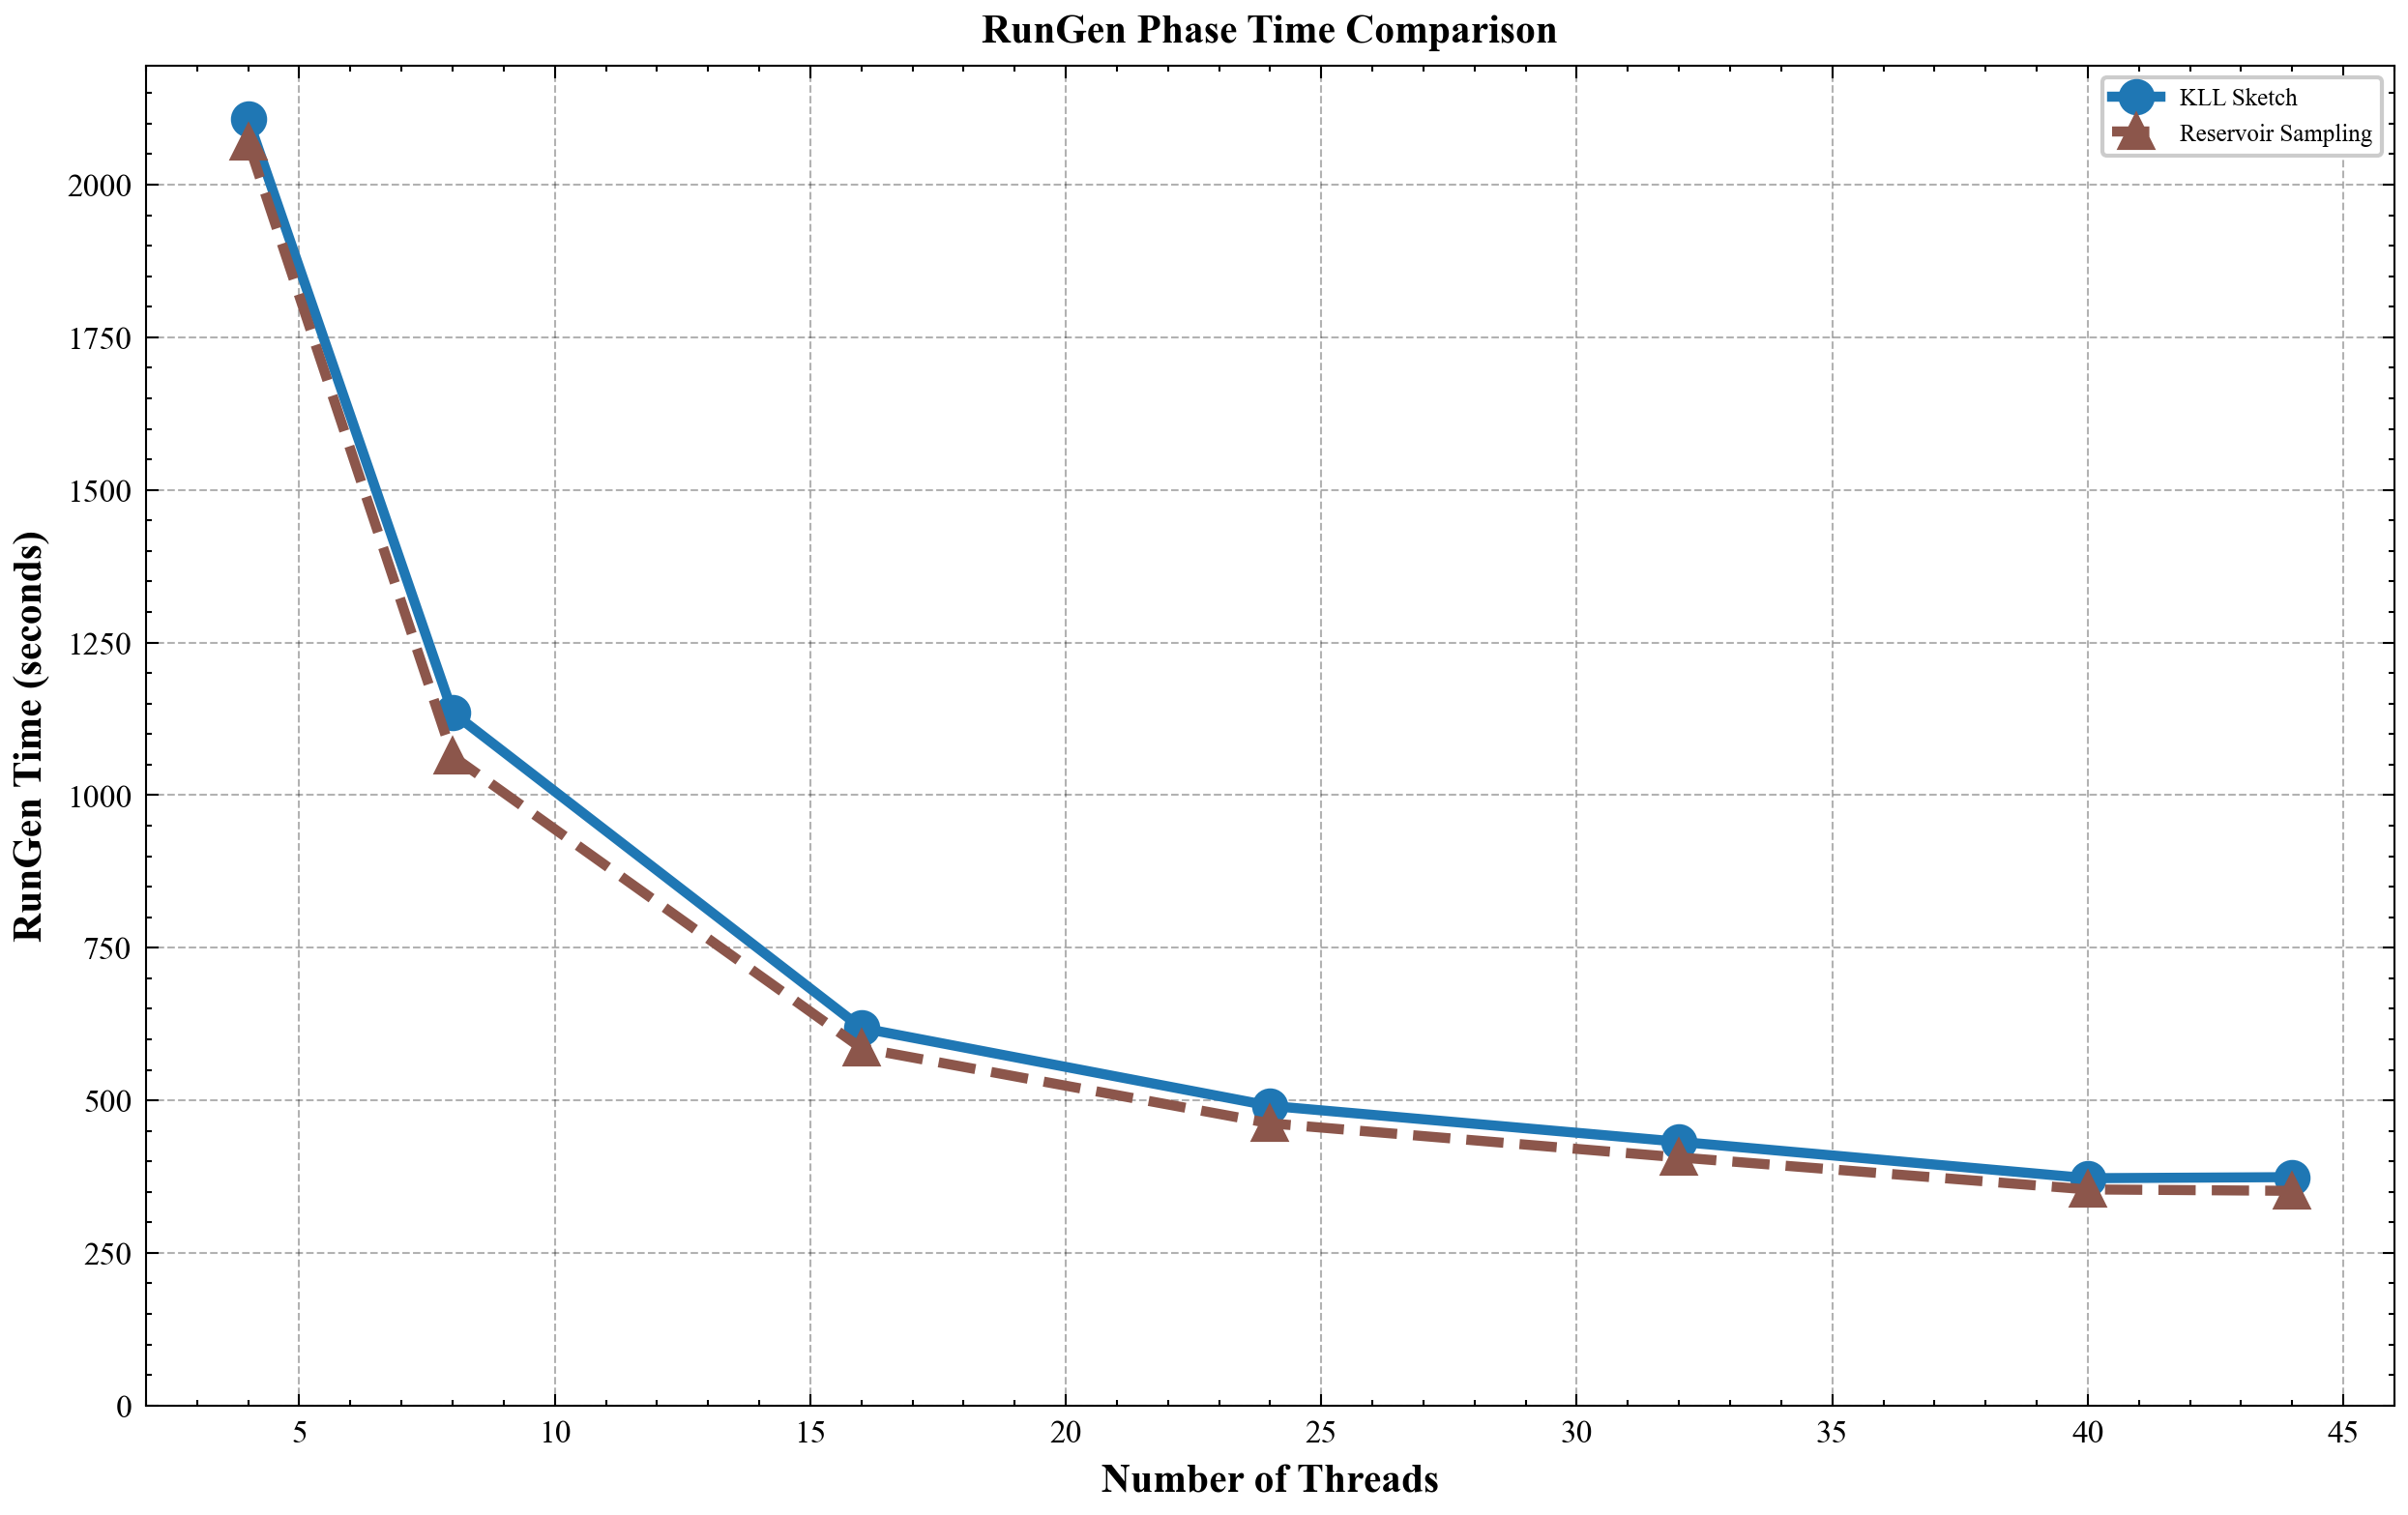

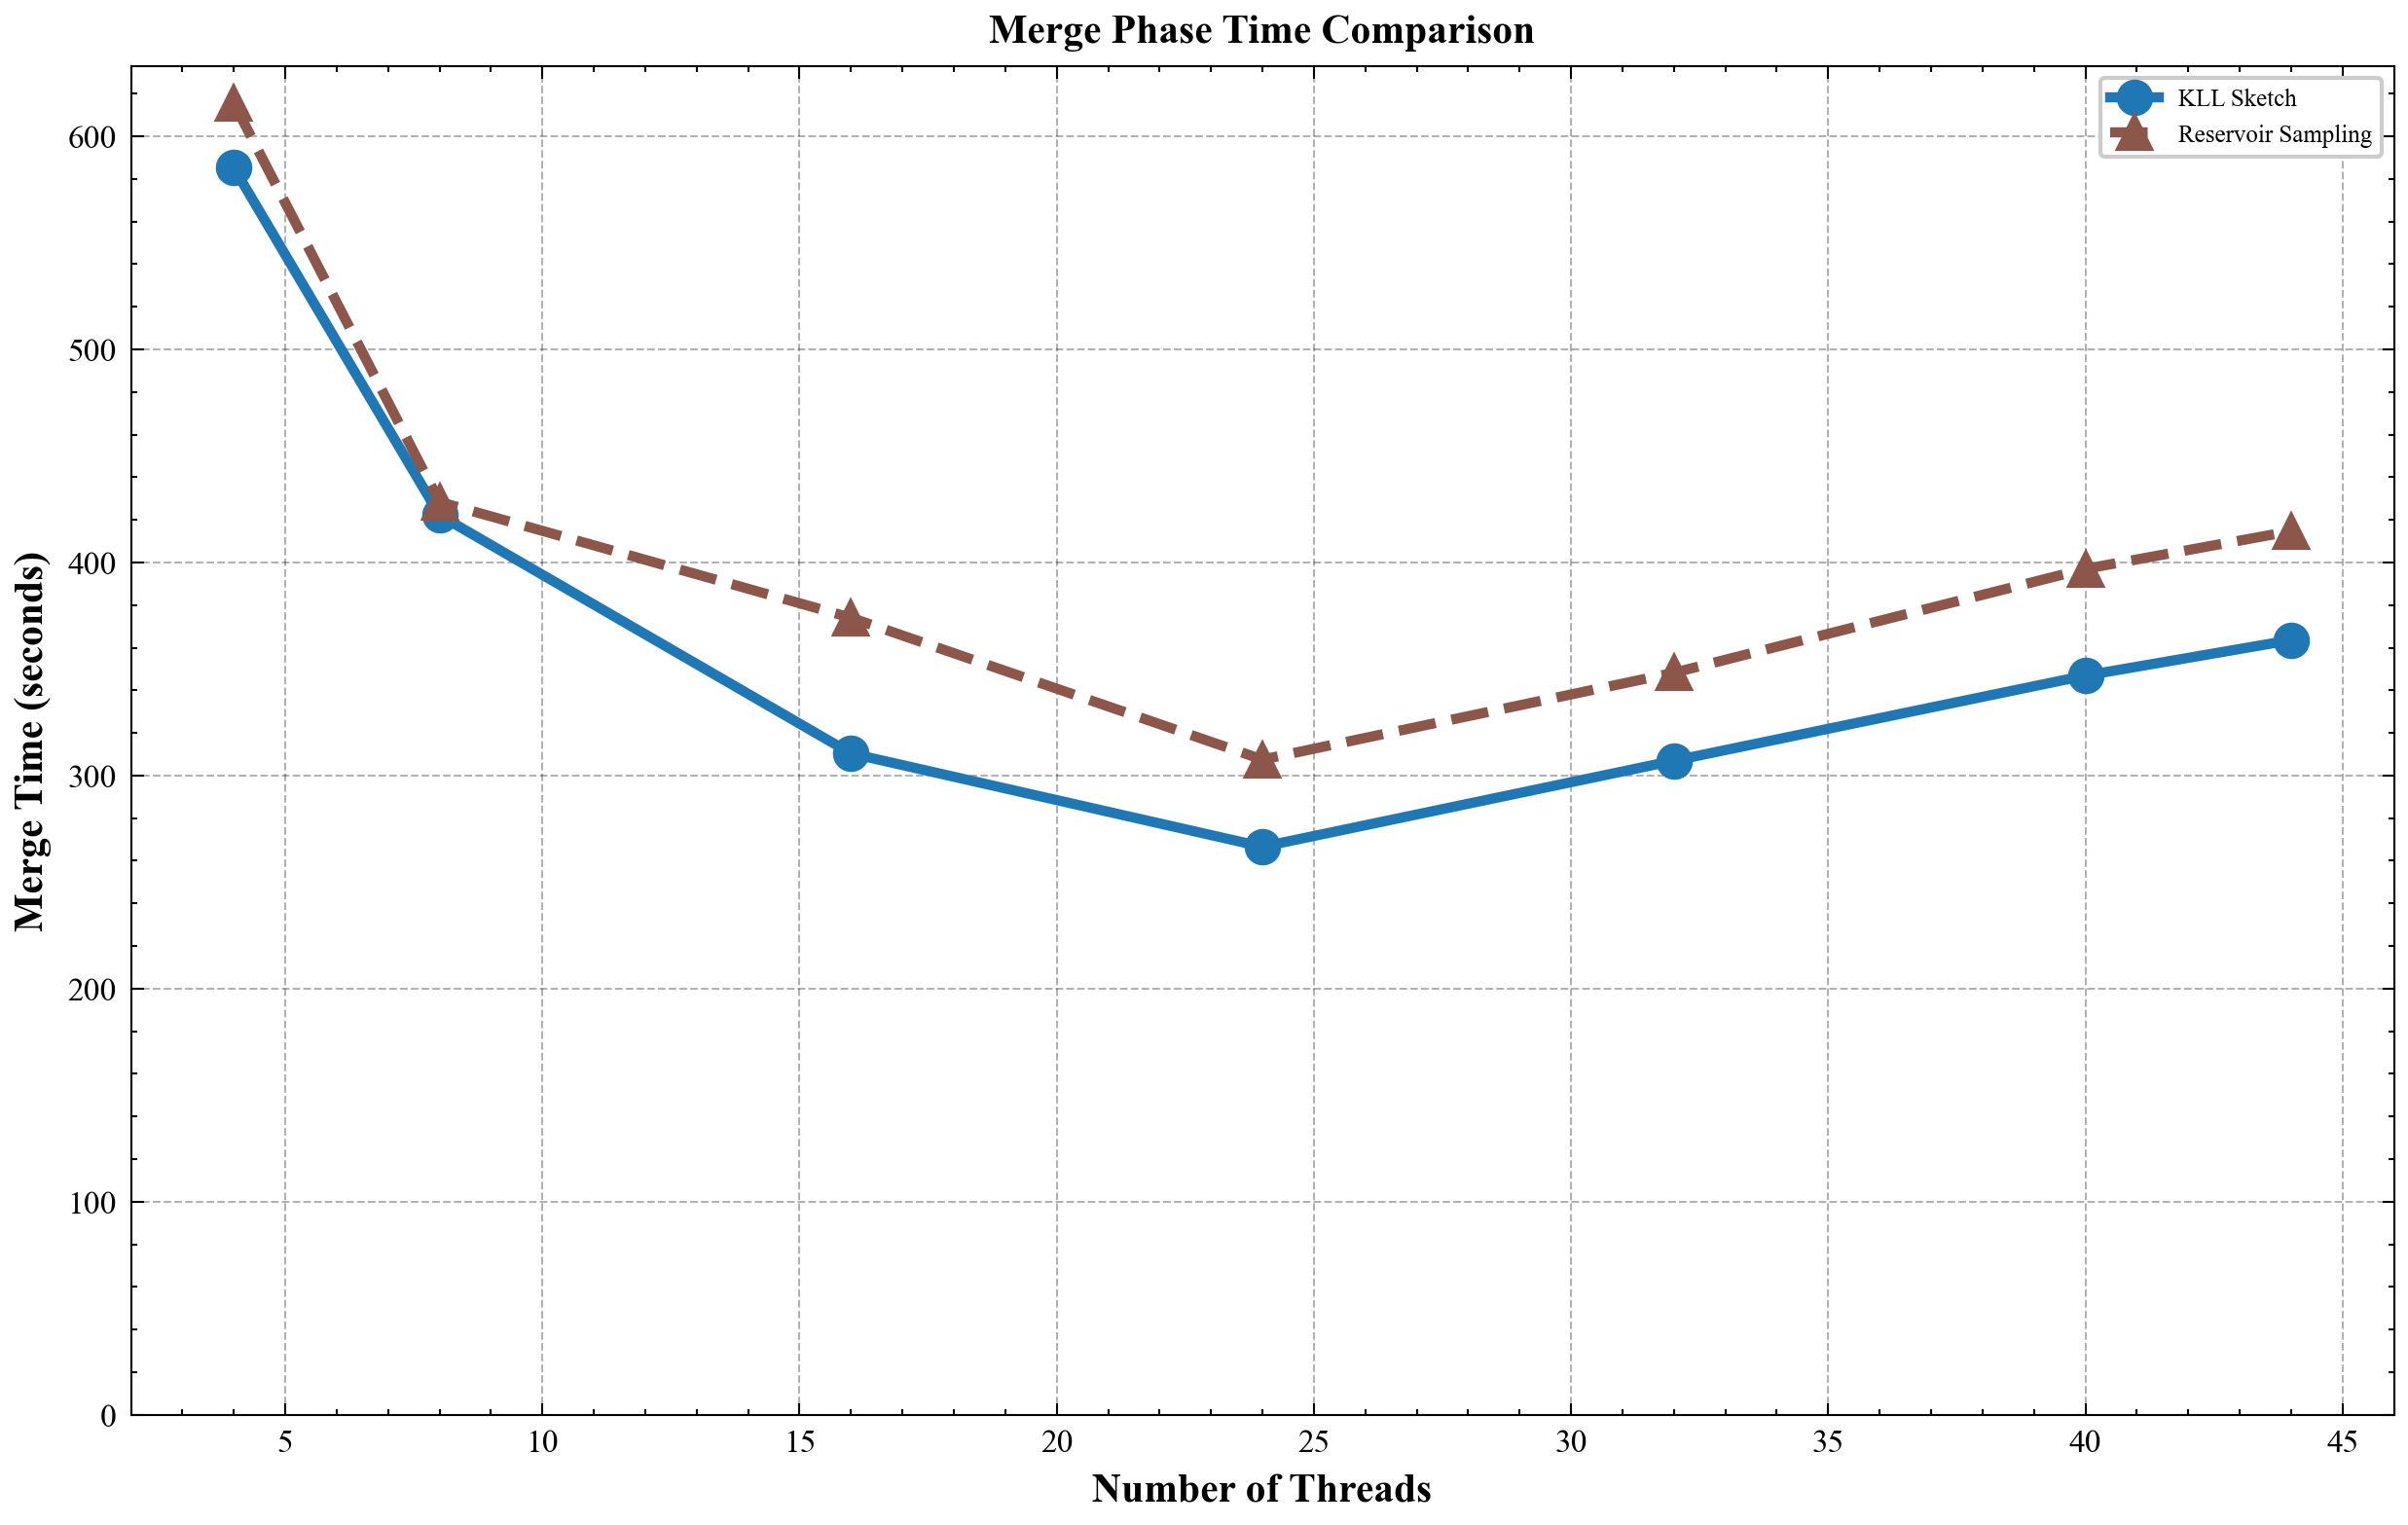

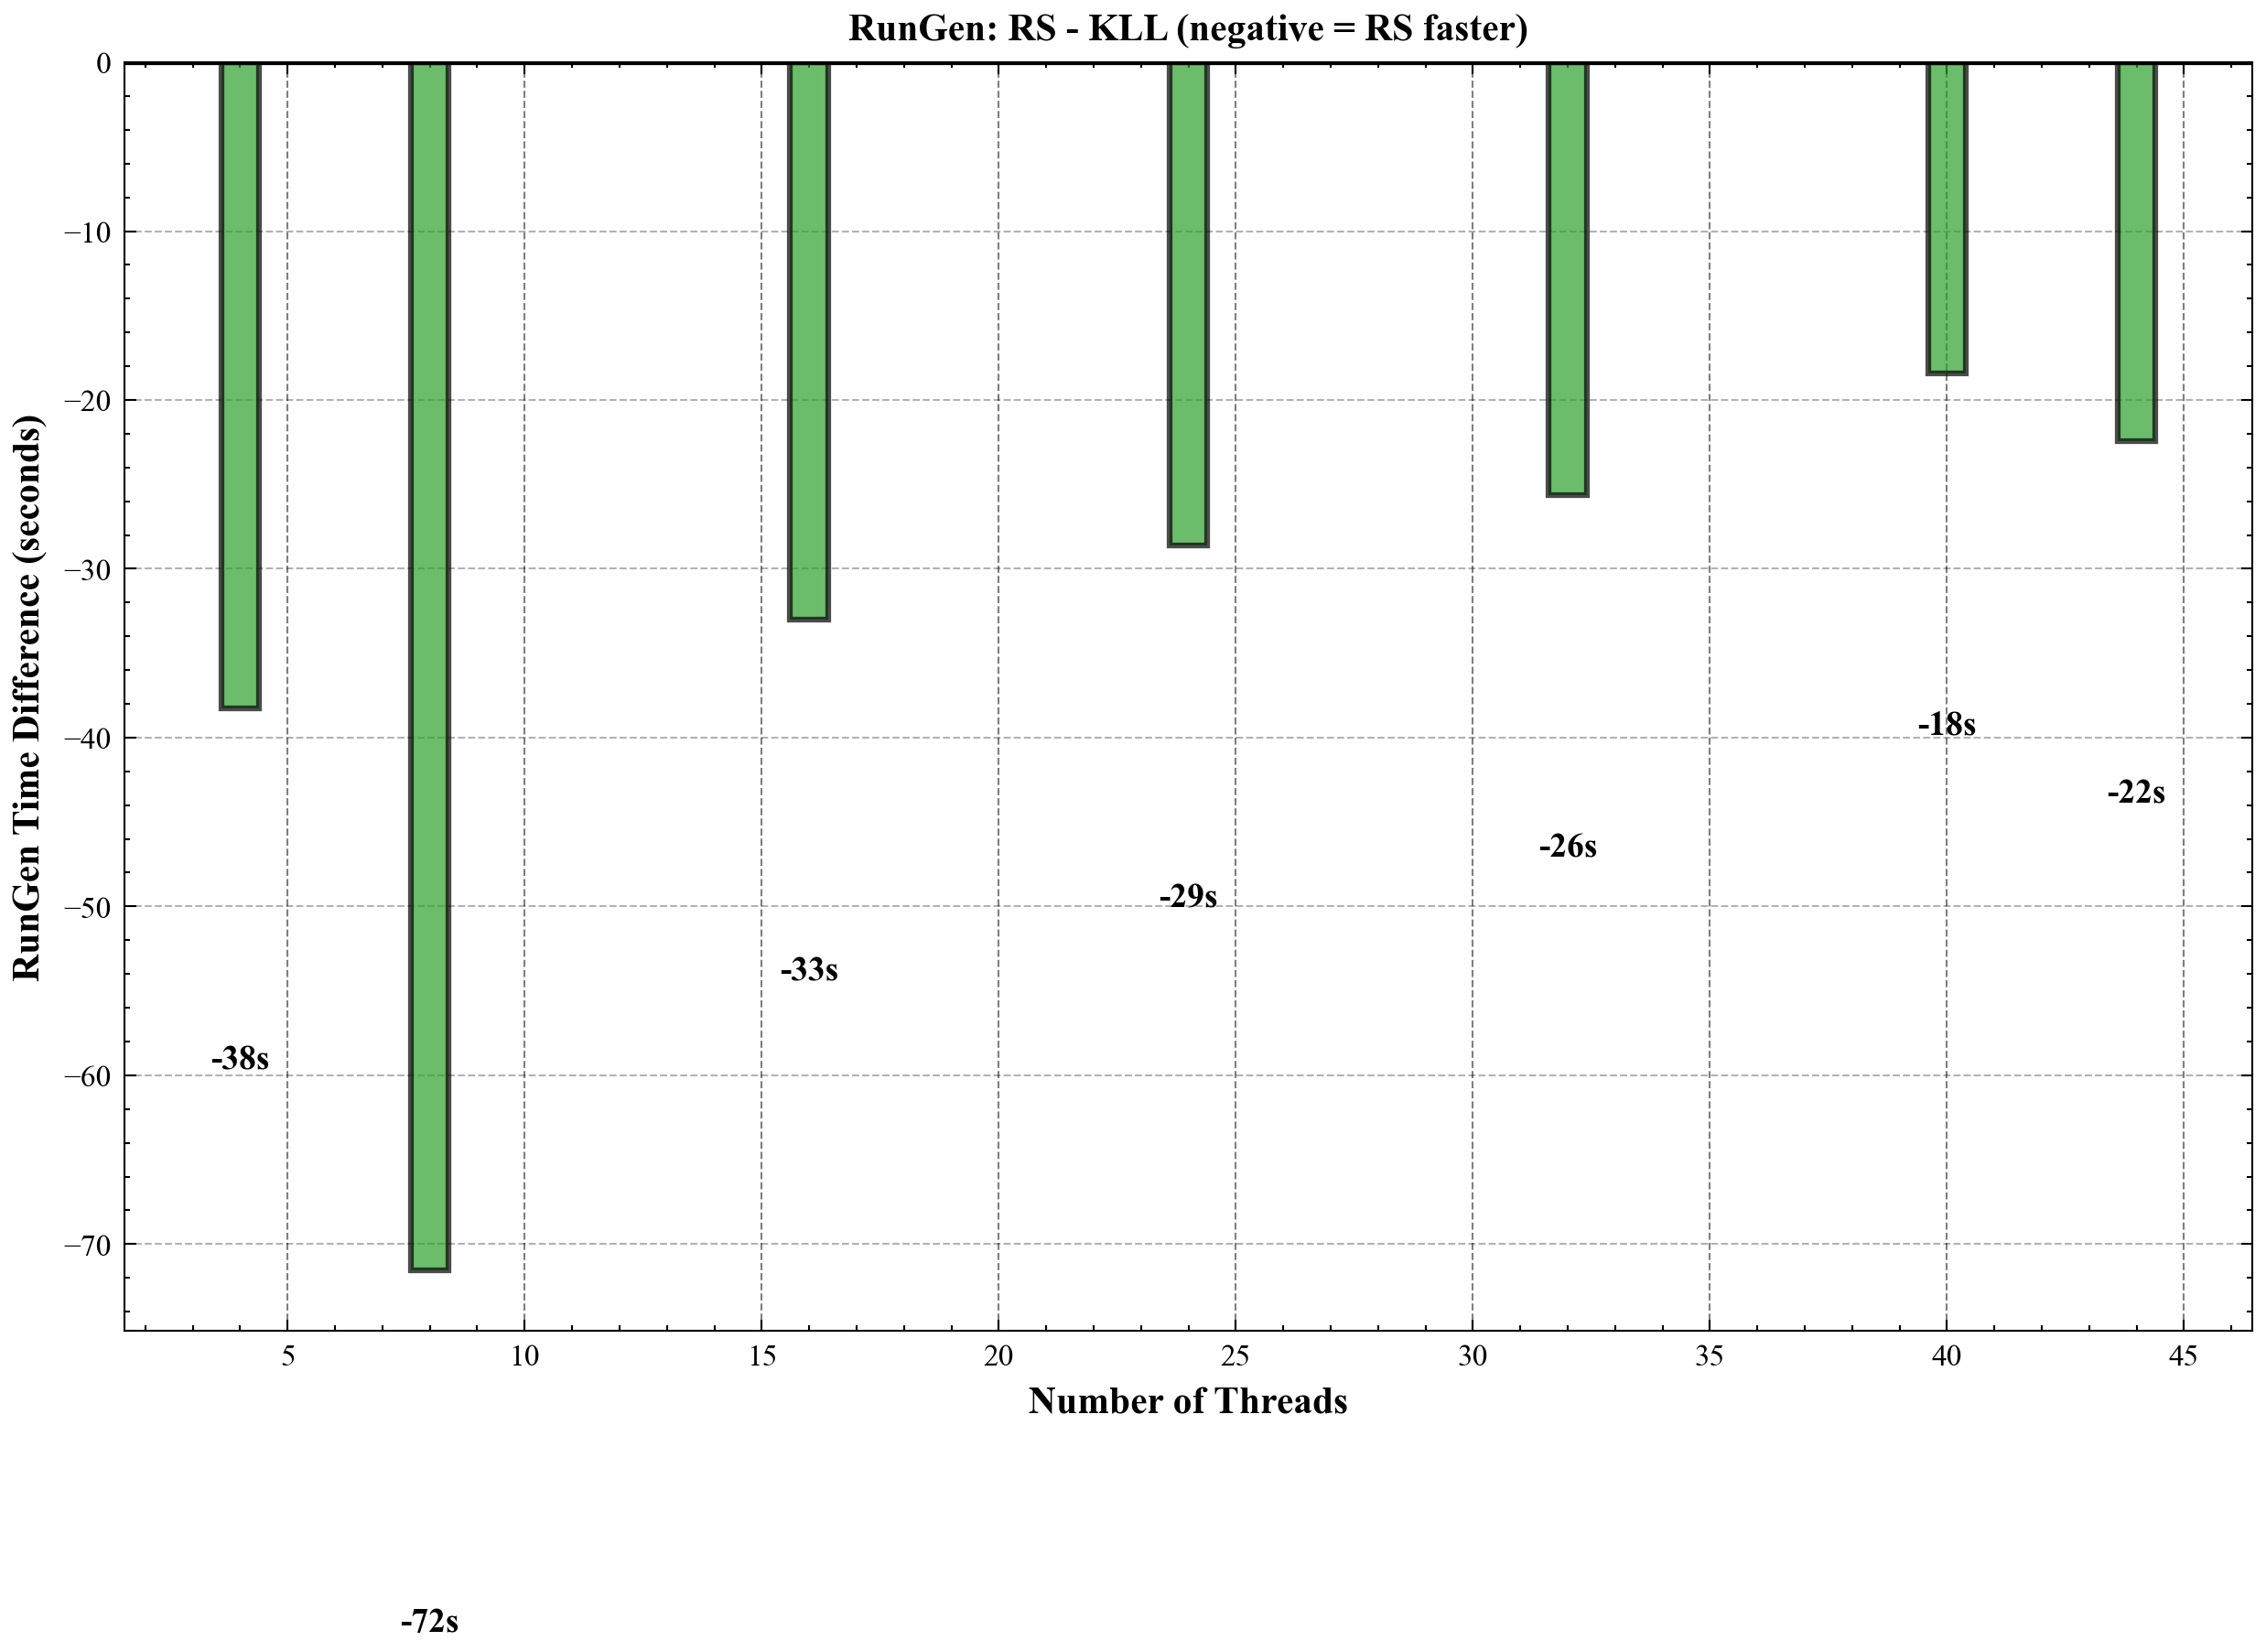

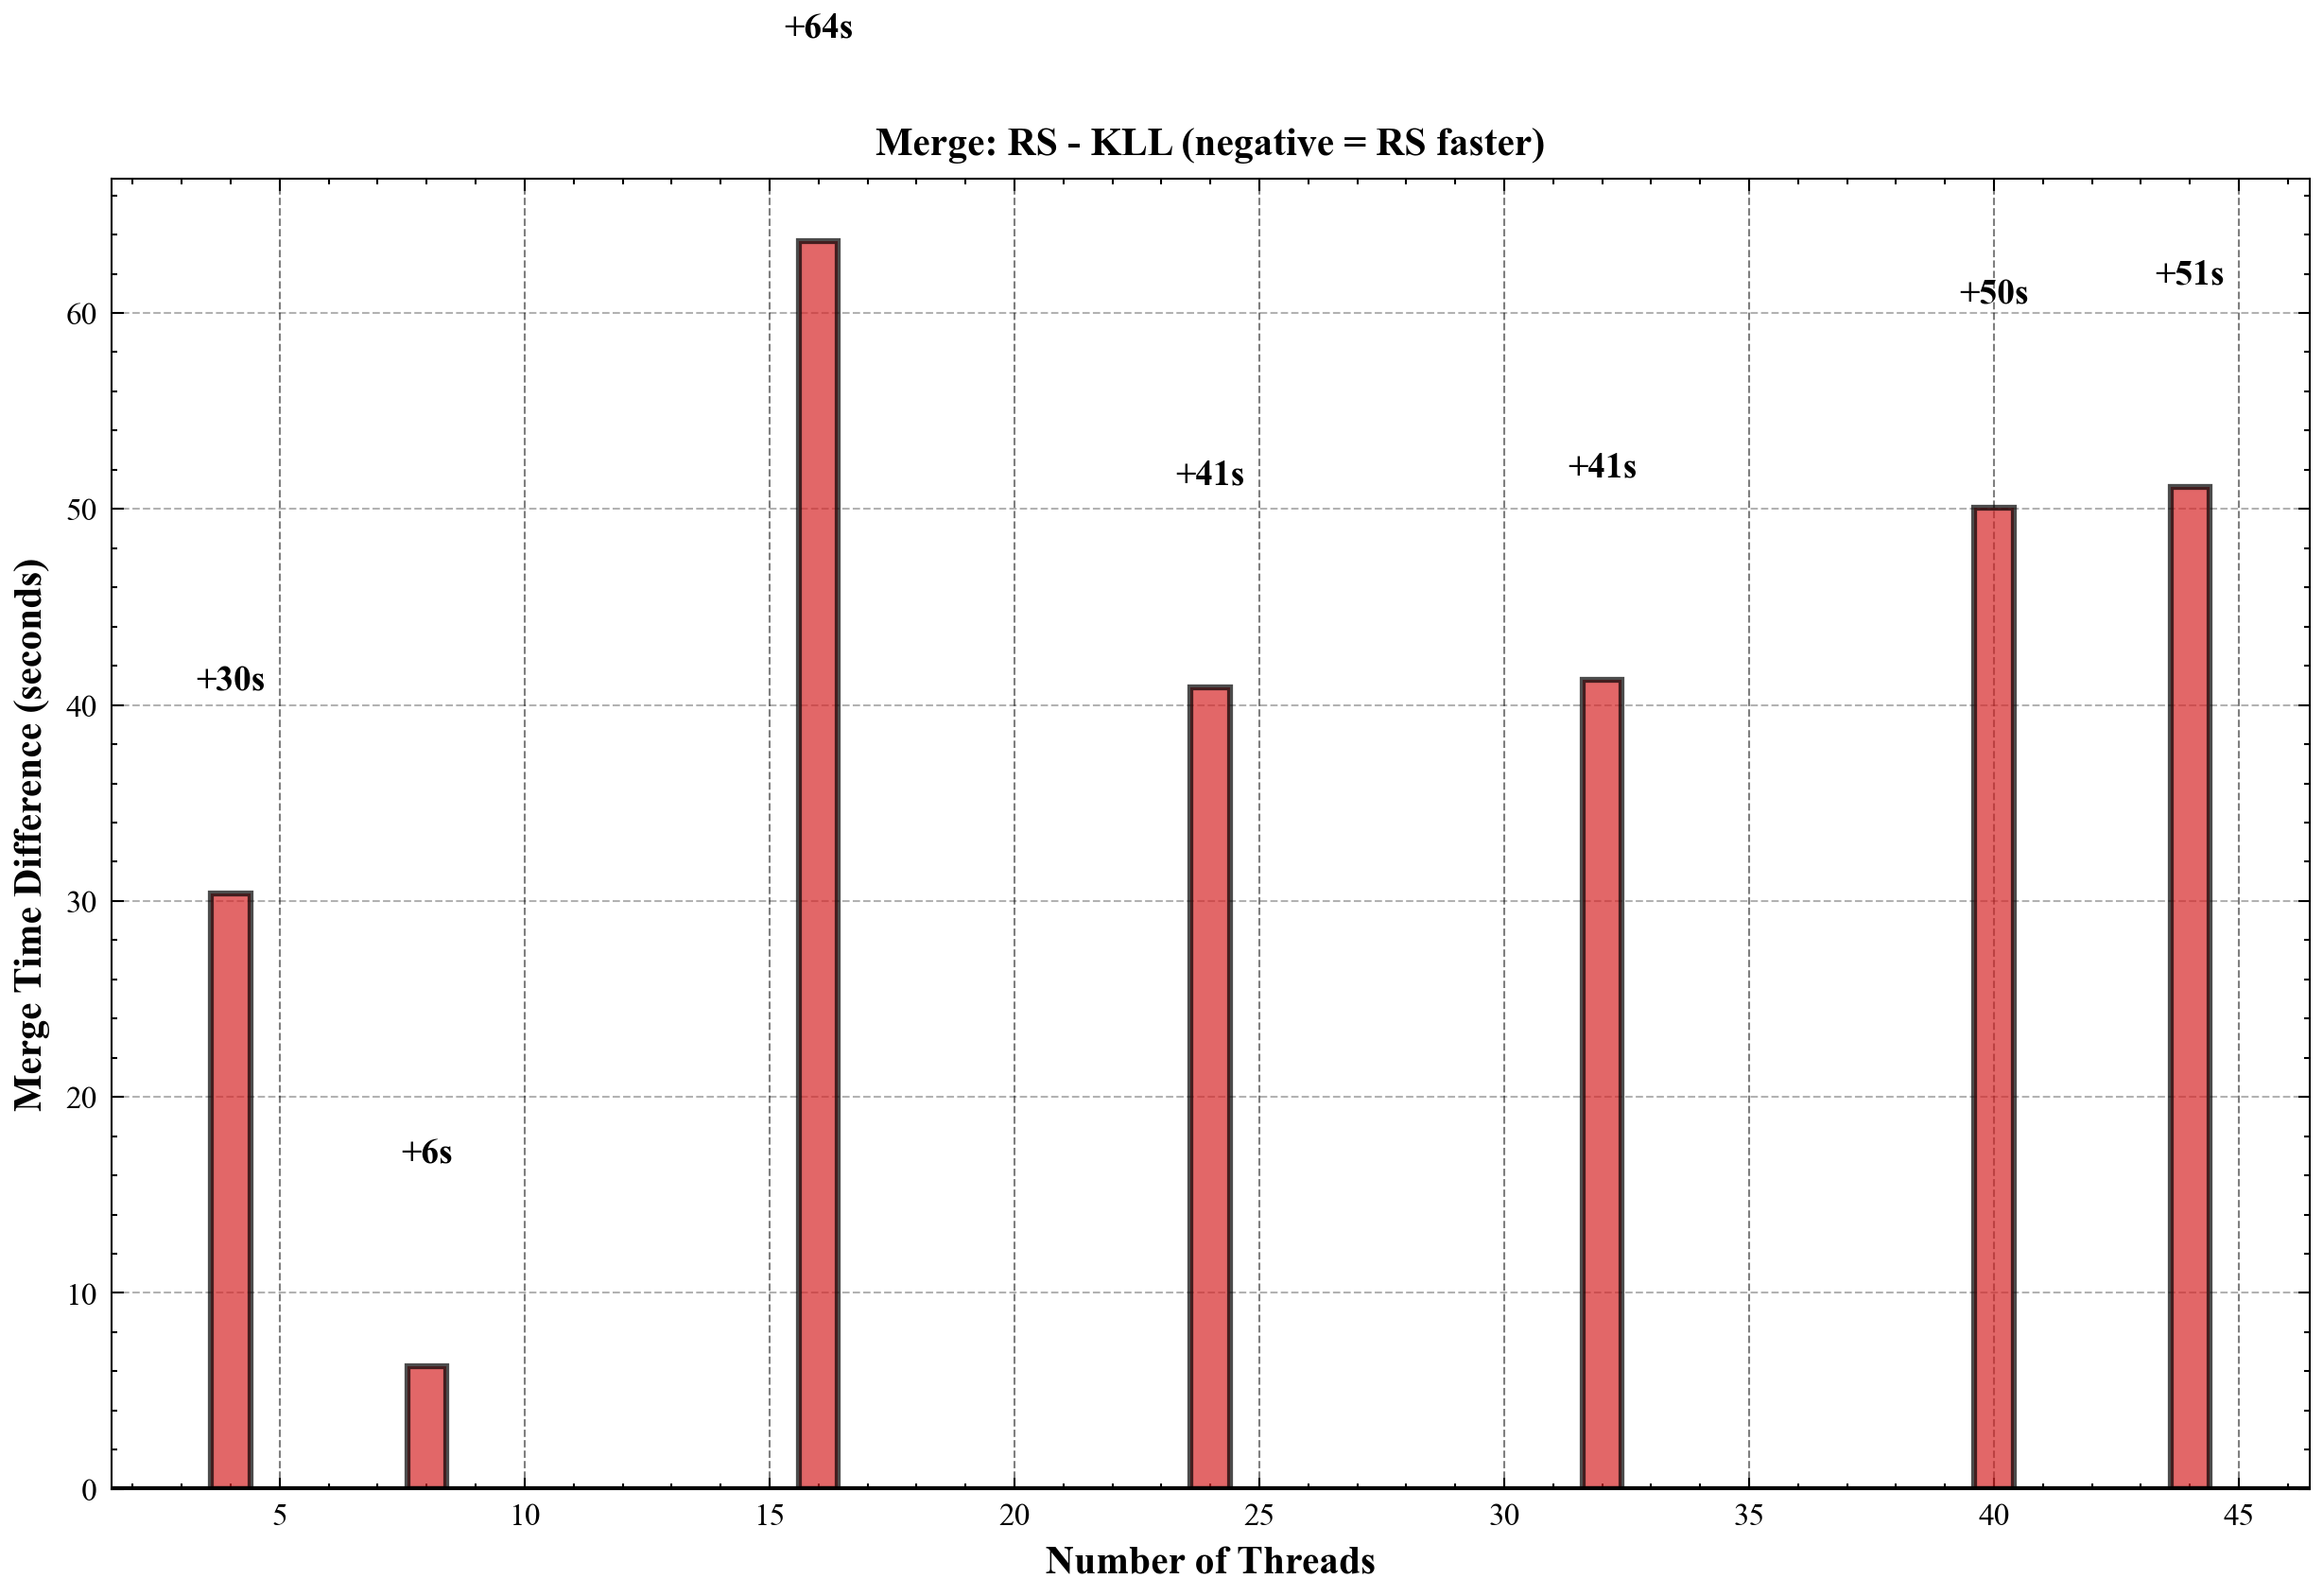


PHASE-BY-PHASE TIME ANALYSIS: KLL vs RESERVOIR SAMPLING
 Threads  KLL RunGen  RS RunGen  RunGen Diff  KLL Merge  RS Merge  Merge Diff  Total Diff
       4      2107.5     2069.2        -38.3      585.2     615.6        30.4        -7.9
       8      1135.4     1063.8        -71.6      422.2     428.4         6.2       -65.3
      16       618.5      585.5        -33.0      310.4     374.1        63.7        30.7
      24       490.9      462.3        -28.6      266.6     307.5        40.9        12.3
      32       432.1      406.4        -25.7      307.0     348.2        41.3        15.6
      40       372.4      354.0        -18.4      346.9     397.0        50.1        31.7
      44       374.2      351.7        -22.5      363.6     414.7        51.1        28.7

📊 Phase-by-Phase Analysis:

RunGen Phase:
  - Avg RS speedup: 34.0s (4.3%)
  - Best RS speedup: 18.4s at 40 threads

Merge Phase:
  - Avg RS impact: +40.5s (+10.9%)
  - RS slower due to 40.5s imbalance penalty

Net Result:

In [9]:
# Phase-by-phase comparison: RunGen and Merge times
df_exp1_sorted = df_exp1.sort_values('threads')
df_exp4_sorted = df_exp4.sort_values('threads')
threads = df_exp1_sorted['threads'].values

# Plot 1: RunGen Time Comparison
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(threads, df_exp1_sorted['rungen_time'], 'o-', lw=2.5, markersize=8, 
         color='#1f77b4', label='KLL Sketch')
ax1.plot(threads, df_exp4_sorted['rungen_time'], '^--', lw=2.5, markersize=8, 
         color='#8c564b', label='Reservoir Sampling')
ax1.set_xlabel('Number of Threads', fontweight='bold')
ax1.set_ylabel('RunGen Time (seconds)', fontweight='bold')
ax1.set_title('RunGen Phase Time Comparison', fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.set_ylim(bottom=0)
plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp4_rungen_time_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Merge Time Comparison
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(threads, df_exp1_sorted['merge_time'], 'o-', lw=2.5, markersize=8, 
         color='#1f77b4', label='KLL Sketch')
ax2.plot(threads, df_exp4_sorted['merge_time'], '^--', lw=2.5, markersize=8, 
         color='#8c564b', label='Reservoir Sampling')
ax2.set_xlabel('Number of Threads', fontweight='bold')
ax2.set_ylabel('Merge Time (seconds)', fontweight='bold')
ax2.set_title('Merge Phase Time Comparison', fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.set_ylim(bottom=0)
plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp4_merge_time_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: RunGen Time Difference (RS - KLL)
rungen_diff = df_exp4_sorted['rungen_time'].values - df_exp1_sorted['rungen_time'].values
bar_colors_rg = ['#2ca02c' if diff < 0 else '#d62728' for diff in rungen_diff]
fig3, ax3 = plt.subplots(figsize=(10, 6))
ax3.bar(threads, rungen_diff, color=bar_colors_rg, alpha=0.7, edgecolor='black', linewidth=1.5)
ax3.axhline(y=0, color='black', linestyle='-', lw=1.5)
for i, (thread, diff) in enumerate(zip(threads, rungen_diff)):
    label_y = diff + (20 if diff > 0 else -20)
    va = 'bottom' if diff > 0 else 'top'
    ax3.text(thread, label_y, f'{diff:+.0f}s', ha='center', va=va, fontweight='bold', fontsize=9)
ax3.set_xlabel('Number of Threads', fontweight='bold')
ax3.set_ylabel('RunGen Time Difference (seconds)', fontweight='bold')
ax3.set_title('RunGen: RS - KLL (negative = RS faster)', fontweight='bold')
ax3.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp4_rungen_time_difference.png'), dpi=300, bbox_inches='tight')
plt.show()

# Plot 4: Merge Time Difference (RS - KLL)
merge_diff = df_exp4_sorted['merge_time'].values - df_exp1_sorted['merge_time'].values
bar_colors_mg = ['#2ca02c' if diff < 0 else '#d62728' for diff in merge_diff]
fig4, ax4 = plt.subplots(figsize=(10, 6))
ax4.bar(threads, merge_diff, color=bar_colors_mg, alpha=0.7, edgecolor='black', linewidth=1.5)
ax4.axhline(y=0, color='black', linestyle='-', lw=1.5)
for i, (thread, diff) in enumerate(zip(threads, merge_diff)):
    label_y = diff + (10 if diff > 0 else -10)
    va = 'bottom' if diff > 0 else 'top'
    ax4.text(thread, label_y, f'{diff:+.0f}s', ha='center', va=va, fontweight='bold', fontsize=9)
ax4.set_xlabel('Number of Threads', fontweight='bold')
ax4.set_ylabel('Merge Time Difference (seconds)', fontweight='bold')
ax4.set_title('Merge: RS - KLL (negative = RS faster)', fontweight='bold')
ax4.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp4_merge_time_difference.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print detailed phase analysis
print("\n" + "="*100)
print("PHASE-BY-PHASE TIME ANALYSIS: KLL vs RESERVOIR SAMPLING")
print("="*100)
phase_analysis = pd.DataFrame({
    'Threads': threads,
    'KLL RunGen': df_exp1_sorted['rungen_time'].values.round(1),
    'RS RunGen': df_exp4_sorted['rungen_time'].values.round(1),
    'RunGen Diff': rungen_diff.round(1),
    'KLL Merge': df_exp1_sorted['merge_time'].values.round(1),
    'RS Merge': df_exp4_sorted['merge_time'].values.round(1),
    'Merge Diff': merge_diff.round(1),
    'Total Diff': (df_exp4_sorted['total_time'].values - df_exp1_sorted['total_time'].values).round(1)
})
print(phase_analysis.to_string(index=False))
print("="*100)

print(f"\n📊 Phase-by-Phase Analysis:")
print(f"\nRunGen Phase:")
print(f"  - Avg RS speedup: {-rungen_diff.mean():.1f}s ({-rungen_diff.mean()/df_exp1_sorted['rungen_time'].mean()*100:.1f}%)")
print(f"  - Best RS speedup: {-rungen_diff.max():.1f}s at {threads[rungen_diff.argmax()]:.0f} threads")

print(f"\nMerge Phase:")
merge_pct = merge_diff.mean() / df_exp1_sorted['merge_time'].mean() * 100
print(f"  - Avg RS impact: {merge_diff.mean():+.1f}s ({merge_pct:+.1f}%)")
print(f"  - RS {'slower' if merge_diff.mean() > 0 else 'faster'} due to {abs(merge_diff.mean()):.1f}s imbalance penalty")

total_diff = df_exp4_sorted['total_time'].values - df_exp1_sorted['total_time'].values
print(f"\nNet Result:")
print(f"  - Avg total: {total_diff.mean():+.1f}s ({total_diff.mean()/df_exp1_sorted['total_time'].mean()*100:+.1f}%)")
if total_diff.mean() < 0:
    print(f"  - RS wins due to RunGen savings outweighing Merge penalty")
else:
    print(f"  - KLL wins - Merge penalty from imbalance outweighs RunGen savings")

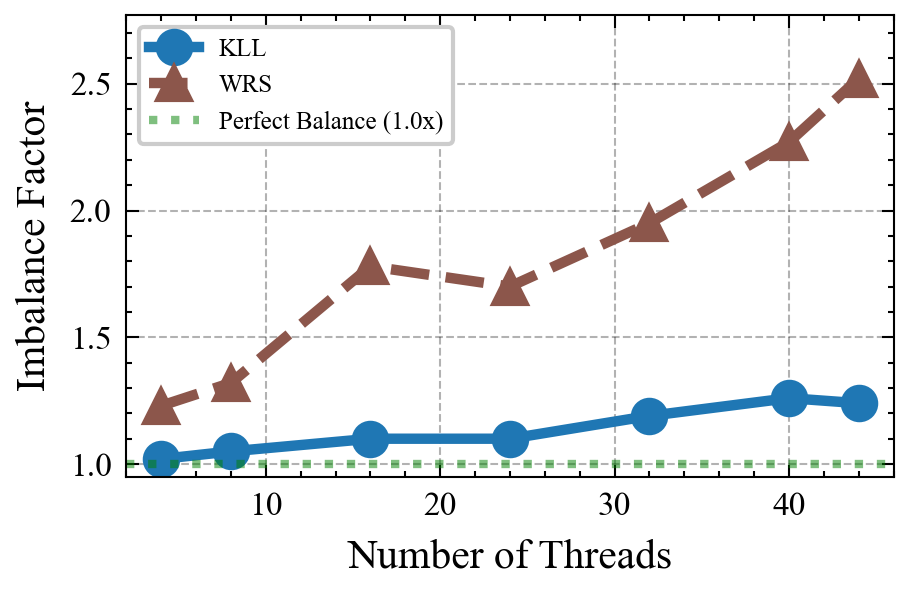


PARTITION IMBALANCE FACTOR TABLE
 Threads  Merge Passes (KLL)  KLL Imbalance  Merge Passes (RS)  RS Imbalance  Difference
       4                   1           1.02                  1        1.2300      0.2100
       8                   1           1.05                  1        1.3200      0.2700
      16                   1           1.10                  1        1.7800      0.6800
      24                   1           1.10                  1        1.7000      0.6000
      32                   2           1.19                  2        1.9500      0.7600
      40                   3           1.26                  3        2.2697      1.0097
      44                   3           1.24                  3        2.5200      1.2800

📊 Partition Imbalance Analysis:

KLL Sketch (Exp1):
  - Best balance: 1.020x at 4 threads
  - Worst balance: 1.260x at 40 threads
  - Average: 1.137x

Reservoir Sampling (Exp4):
  - Best balance: 1.230x at 4 threads
  - Worst balance: 2.520x at 44 threa

In [14]:
# Exp4 Additional Analysis: Partition Imbalance Comparison
# Compare partition quality between KLL and Reservoir Sampling

fig, ax = plt.subplots()

df_exp1_sorted = df_exp1.sort_values('threads')
df_exp4_sorted = df_exp4.sort_values('threads')

threads_exp1 = df_exp1_sorted['threads'].values
threads_exp4 = df_exp4_sorted['threads'].values

# Get partition imbalance from merge operations
imbalance_kll = df_exp1_sorted['partition_imbalance'].values
imbalance_rs = df_exp4_sorted['partition_imbalance'].values

# Plot both
ax.plot(threads_exp1, imbalance_kll, 'o-', lw=2.5, markersize=8, 
        color='#1f77b4', label='KLL')
ax.plot(threads_exp4, imbalance_rs, '^--', lw=2.5, markersize=8, 
        color='#8c564b', label='WRS')

# Add reference line for perfect balance
ax.axhline(y=1.0, color='green', linestyle=':', lw=2, alpha=0.5, label='Perfect Balance (1.0x)')
# ax.axhline(y=1.2, color='orange', linestyle='--', lw=1.5, alpha=0.5, label='Acceptable Threshold (1.2x)')

ax.set_xlabel('Number of Threads')
ax.set_ylabel('Imbalance Factor')
# ax.set_title('Exp4: Partition Quality - KLL vs Reservoir Sampling (LineItem)')
ax.legend(loc='best')
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_xlim(threads_exp1.min() - 2, threads_exp1.max() + 2)
ax.set_ylim(0.95, max(imbalance_kll.max(), imbalance_rs.max()) * 1.1)

plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp4_imbalance_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print detailed partition imbalance table
print("\n" + "="*100)
print("PARTITION IMBALANCE FACTOR TABLE")
print("="*100)
imbalance_comparison = pd.DataFrame({
    'Threads': threads_exp1,
    'Merge Passes (KLL)': df_exp1_sorted['merge_passes'].values,
    'KLL Imbalance': imbalance_kll.round(4),
    'Merge Passes (RS)': df_exp4_sorted['merge_passes'].values,
    'RS Imbalance': imbalance_rs.round(4),
    'Difference': (imbalance_rs - imbalance_kll).round(4)
})
print(imbalance_comparison.to_string(index=False))
print("="*100)

print(f"\n📊 Partition Imbalance Analysis:")
print(f"\nKLL Sketch (Exp1):")
print(f"  - Best balance: {imbalance_kll.min():.3f}x at {threads_exp1[imbalance_kll.argmin()]:.0f} threads")
print(f"  - Worst balance: {imbalance_kll.max():.3f}x at {threads_exp1[imbalance_kll.argmax()]:.0f} threads")
print(f"  - Average: {imbalance_kll.mean():.3f}x")

print(f"\nReservoir Sampling (Exp4):")
print(f"  - Best balance: {imbalance_rs.min():.3f}x at {threads_exp4[imbalance_rs.argmin()]:.0f} threads")
print(f"  - Worst balance: {imbalance_rs.max():.3f}x at {threads_exp4[imbalance_rs.argmax()]:.0f} threads")
print(f"  - Average: {imbalance_rs.mean():.3f}x")

print(f"\nComparison:")
print(f"  - KLL has {'better' if imbalance_kll.mean() < imbalance_rs.mean() else 'worse'} average partition quality")
print(f"  - Difference: {abs(imbalance_kll.mean() - imbalance_rs.mean()):.3f}x")
print(f"  - On skewed LineItem data, KLL's sophisticated sketching provides {(imbalance_rs.mean() / imbalance_kll.mean() - 1) * 100:.1f}% better balance")

In [11]:
# Parse thread-level merge times for detailed imbalance analysis
def parse_thread_times(filepath):
    """Extract individual thread merge times from log file."""
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Find all thread times entries
    thread_times_pattern = r'Thread times: \[([\d, ]+)\]'
    matches = re.findall(thread_times_pattern, content)
    
    if not matches:
        return None
    
    # Parse each run's thread times
    all_runs = []
    for match in matches:
        times = [int(x.strip()) for x in match.split(',')]
        all_runs.append(times)
    
    # Calculate statistics across all runs
    all_times_flat = [t for run in all_runs for t in run]
    
    return {
        'thread_times_per_run': all_runs,
        'min_thread_time': min(all_times_flat),
        'max_thread_time': max(all_times_flat),
        'avg_thread_time': sum(all_times_flat) / len(all_times_flat),
        'std_thread_time': (sum((t - sum(all_times_flat)/len(all_times_flat))**2 for t in all_times_flat) / len(all_times_flat))**0.5,
        'imbalance_spread': max(all_times_flat) - min(all_times_flat),
        'imbalance_ratio': max(all_times_flat) / min(all_times_flat) if min(all_times_flat) > 0 else 0
    }

# Parse thread times for both experiments
print("\n" + "="*100)
print("PARSING THREAD-LEVEL MERGE TIMES")
print("="*100)

exp1_thread_data = []
exp4_thread_data = []

for idx, row in df_exp1.iterrows():
    filepath = os.path.join(LOG_DIR, row['filename'])
    thread_stats = parse_thread_times(filepath)
    if thread_stats:
        thread_stats['threads'] = row['threads']
        thread_stats['experiment'] = 'KLL'
        exp1_thread_data.append(thread_stats)

for idx, row in df_exp4.iterrows():
    filepath = os.path.join(LOG_DIR, row['filename'])
    thread_stats = parse_thread_times(filepath)
    if thread_stats:
        thread_stats['threads'] = row['threads']
        thread_stats['experiment'] = 'RS'
        exp4_thread_data.append(thread_stats)

df_exp1_threads = pd.DataFrame(exp1_thread_data)
df_exp4_threads = pd.DataFrame(exp4_thread_data)

print(f"Parsed thread times for {len(df_exp1_threads)} KLL experiments")
print(f"Parsed thread times for {len(df_exp4_threads)} RS experiments")


PARSING THREAD-LEVEL MERGE TIMES
Parsed thread times for 5 KLL experiments
Parsed thread times for 5 RS experiments


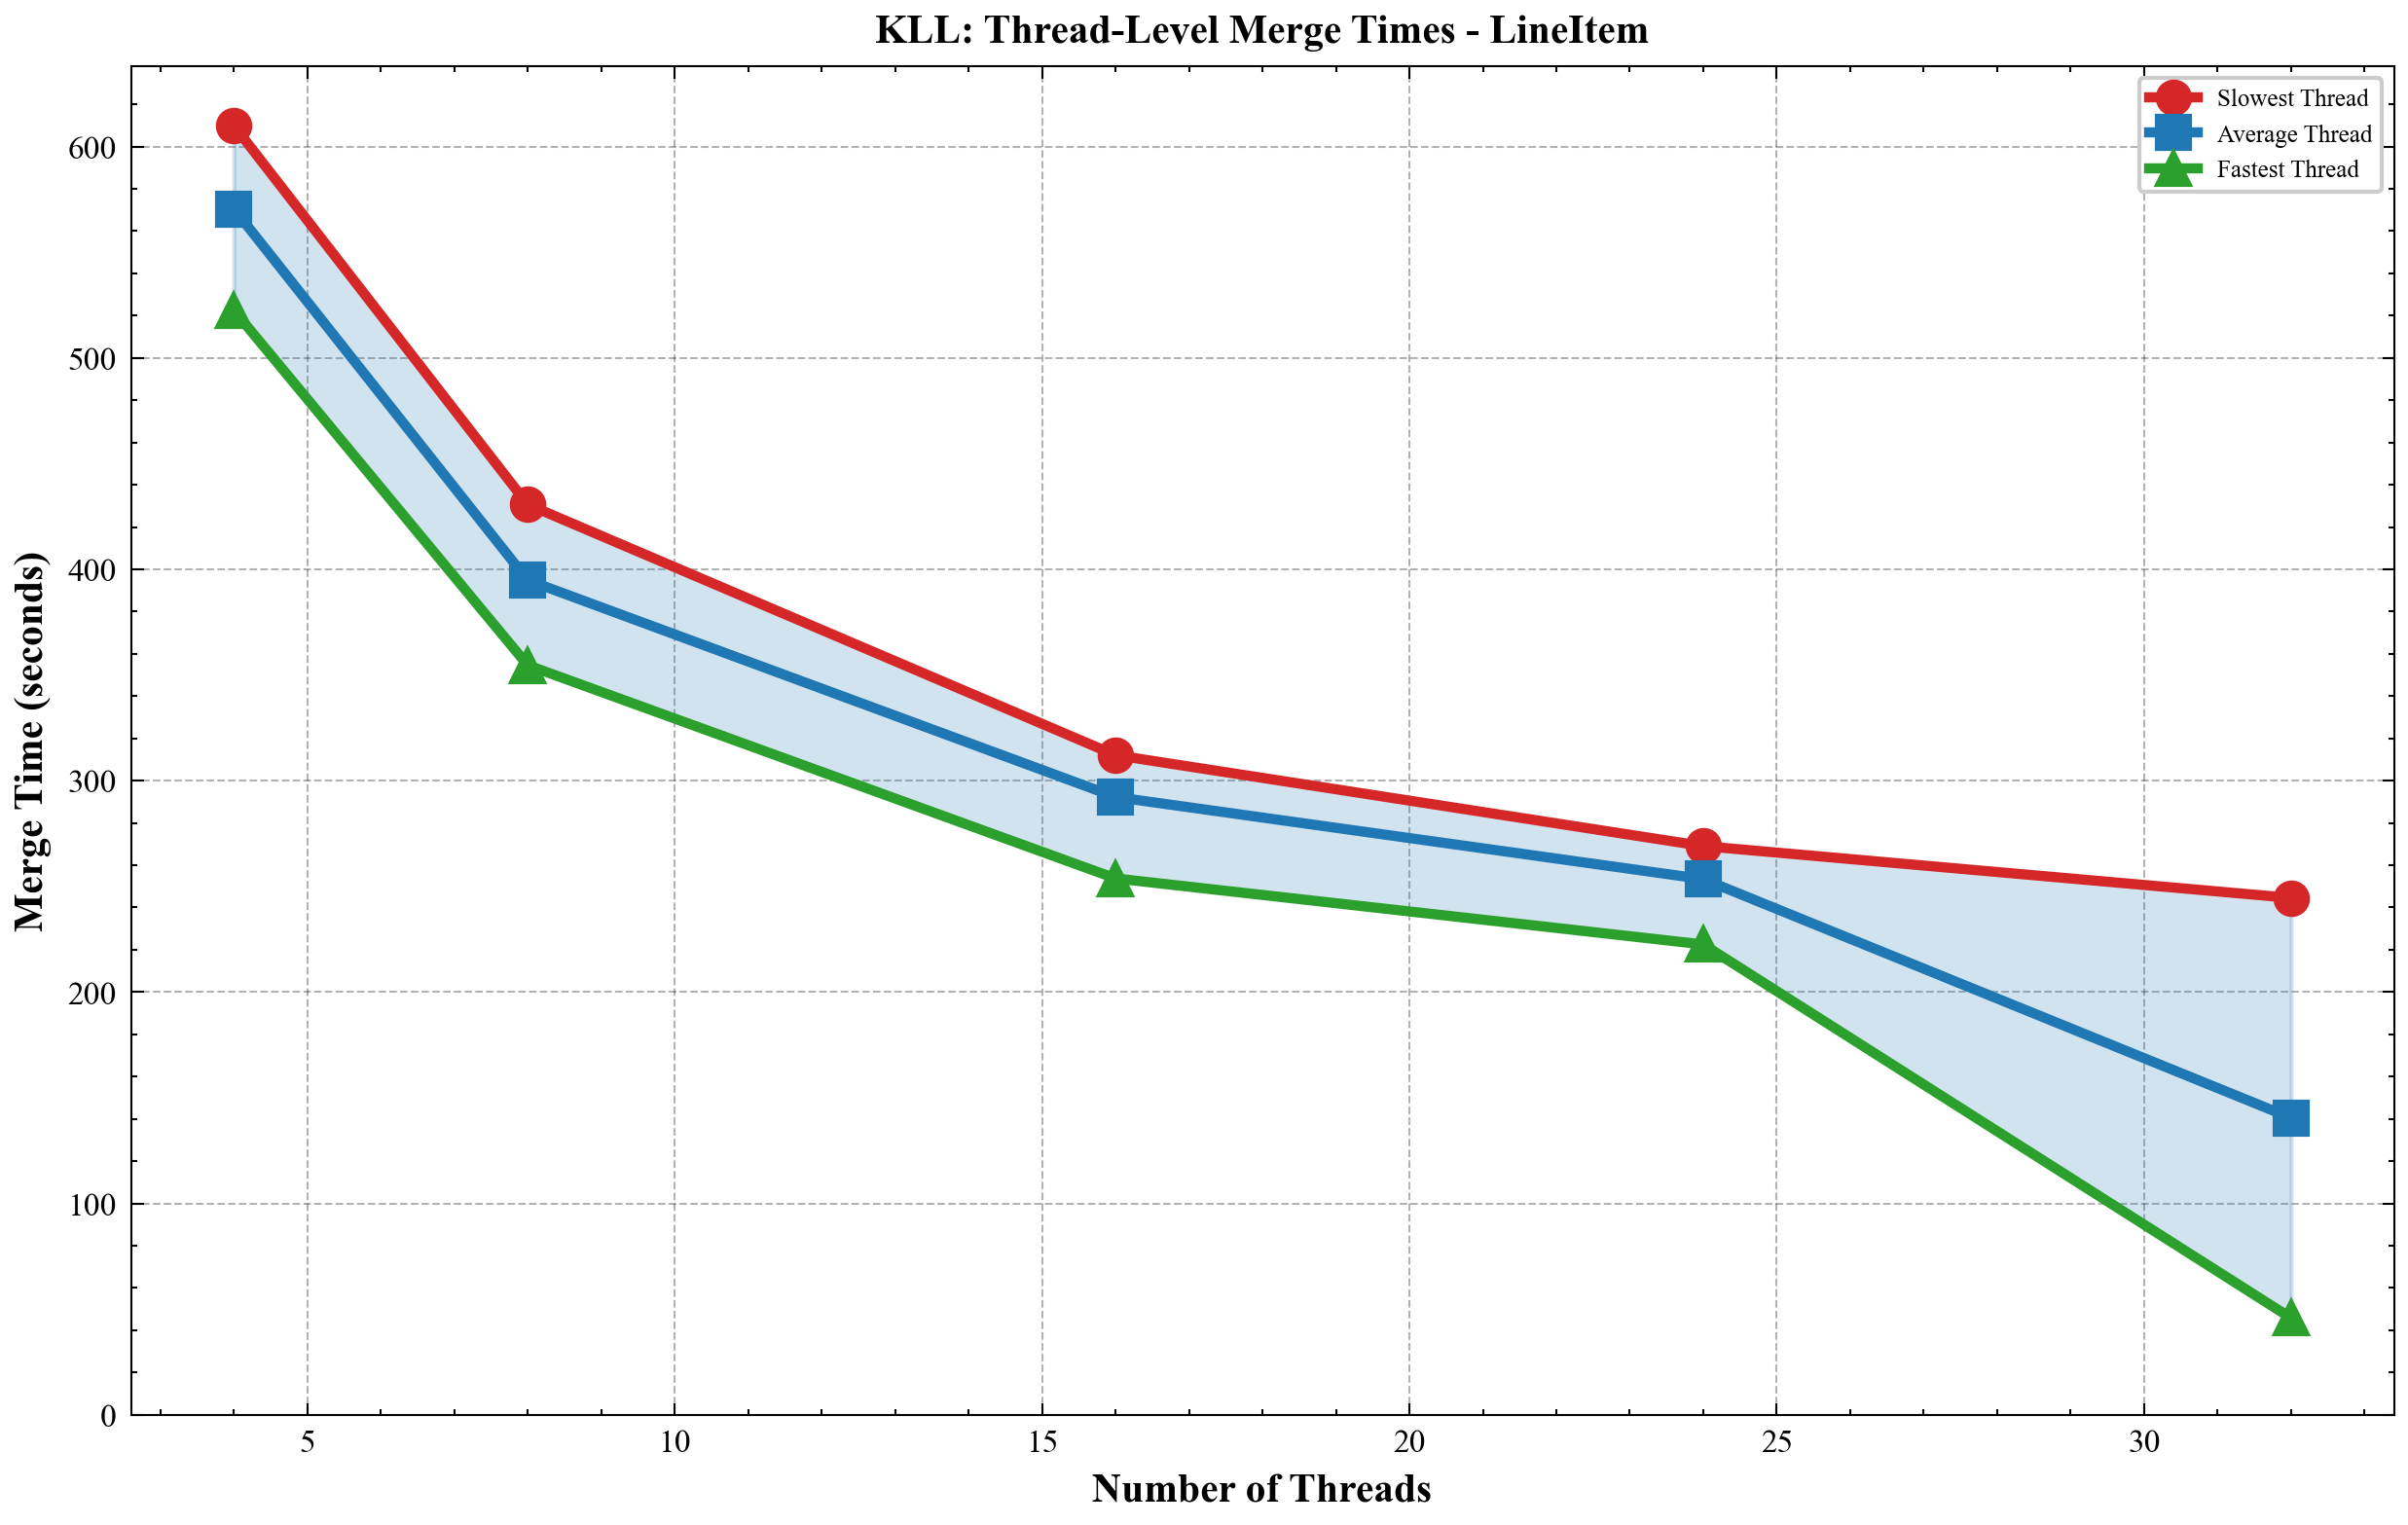

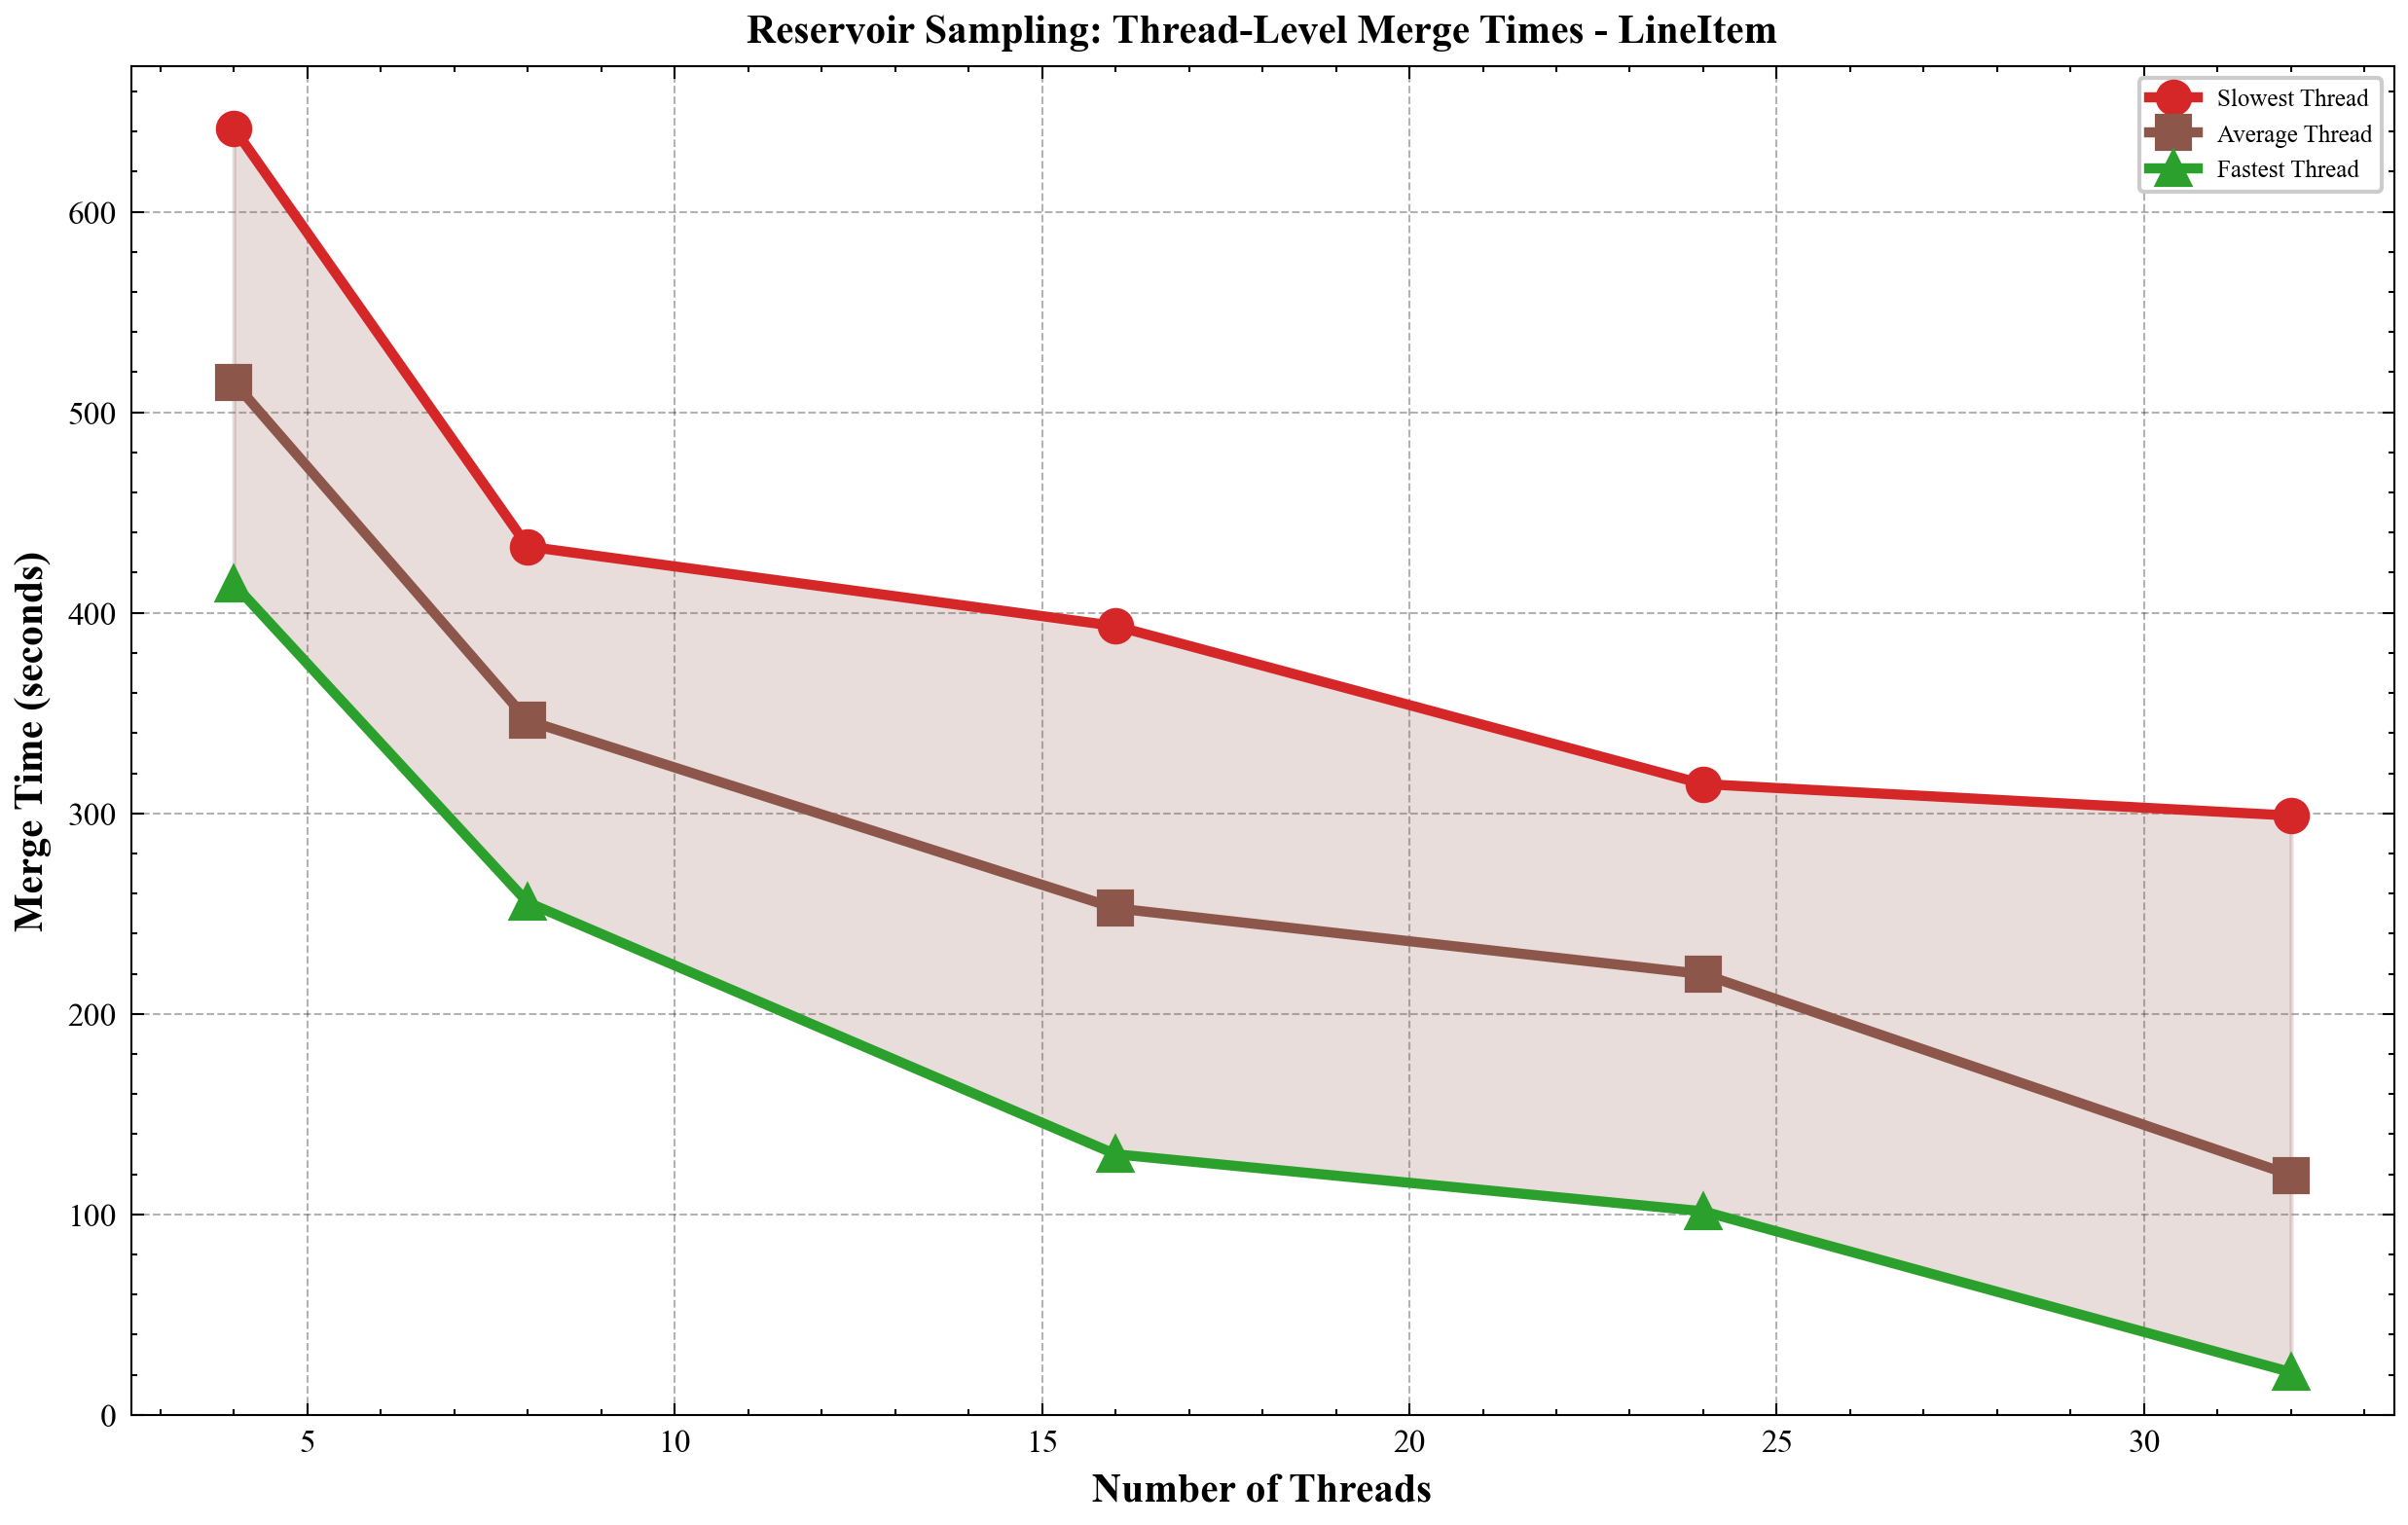

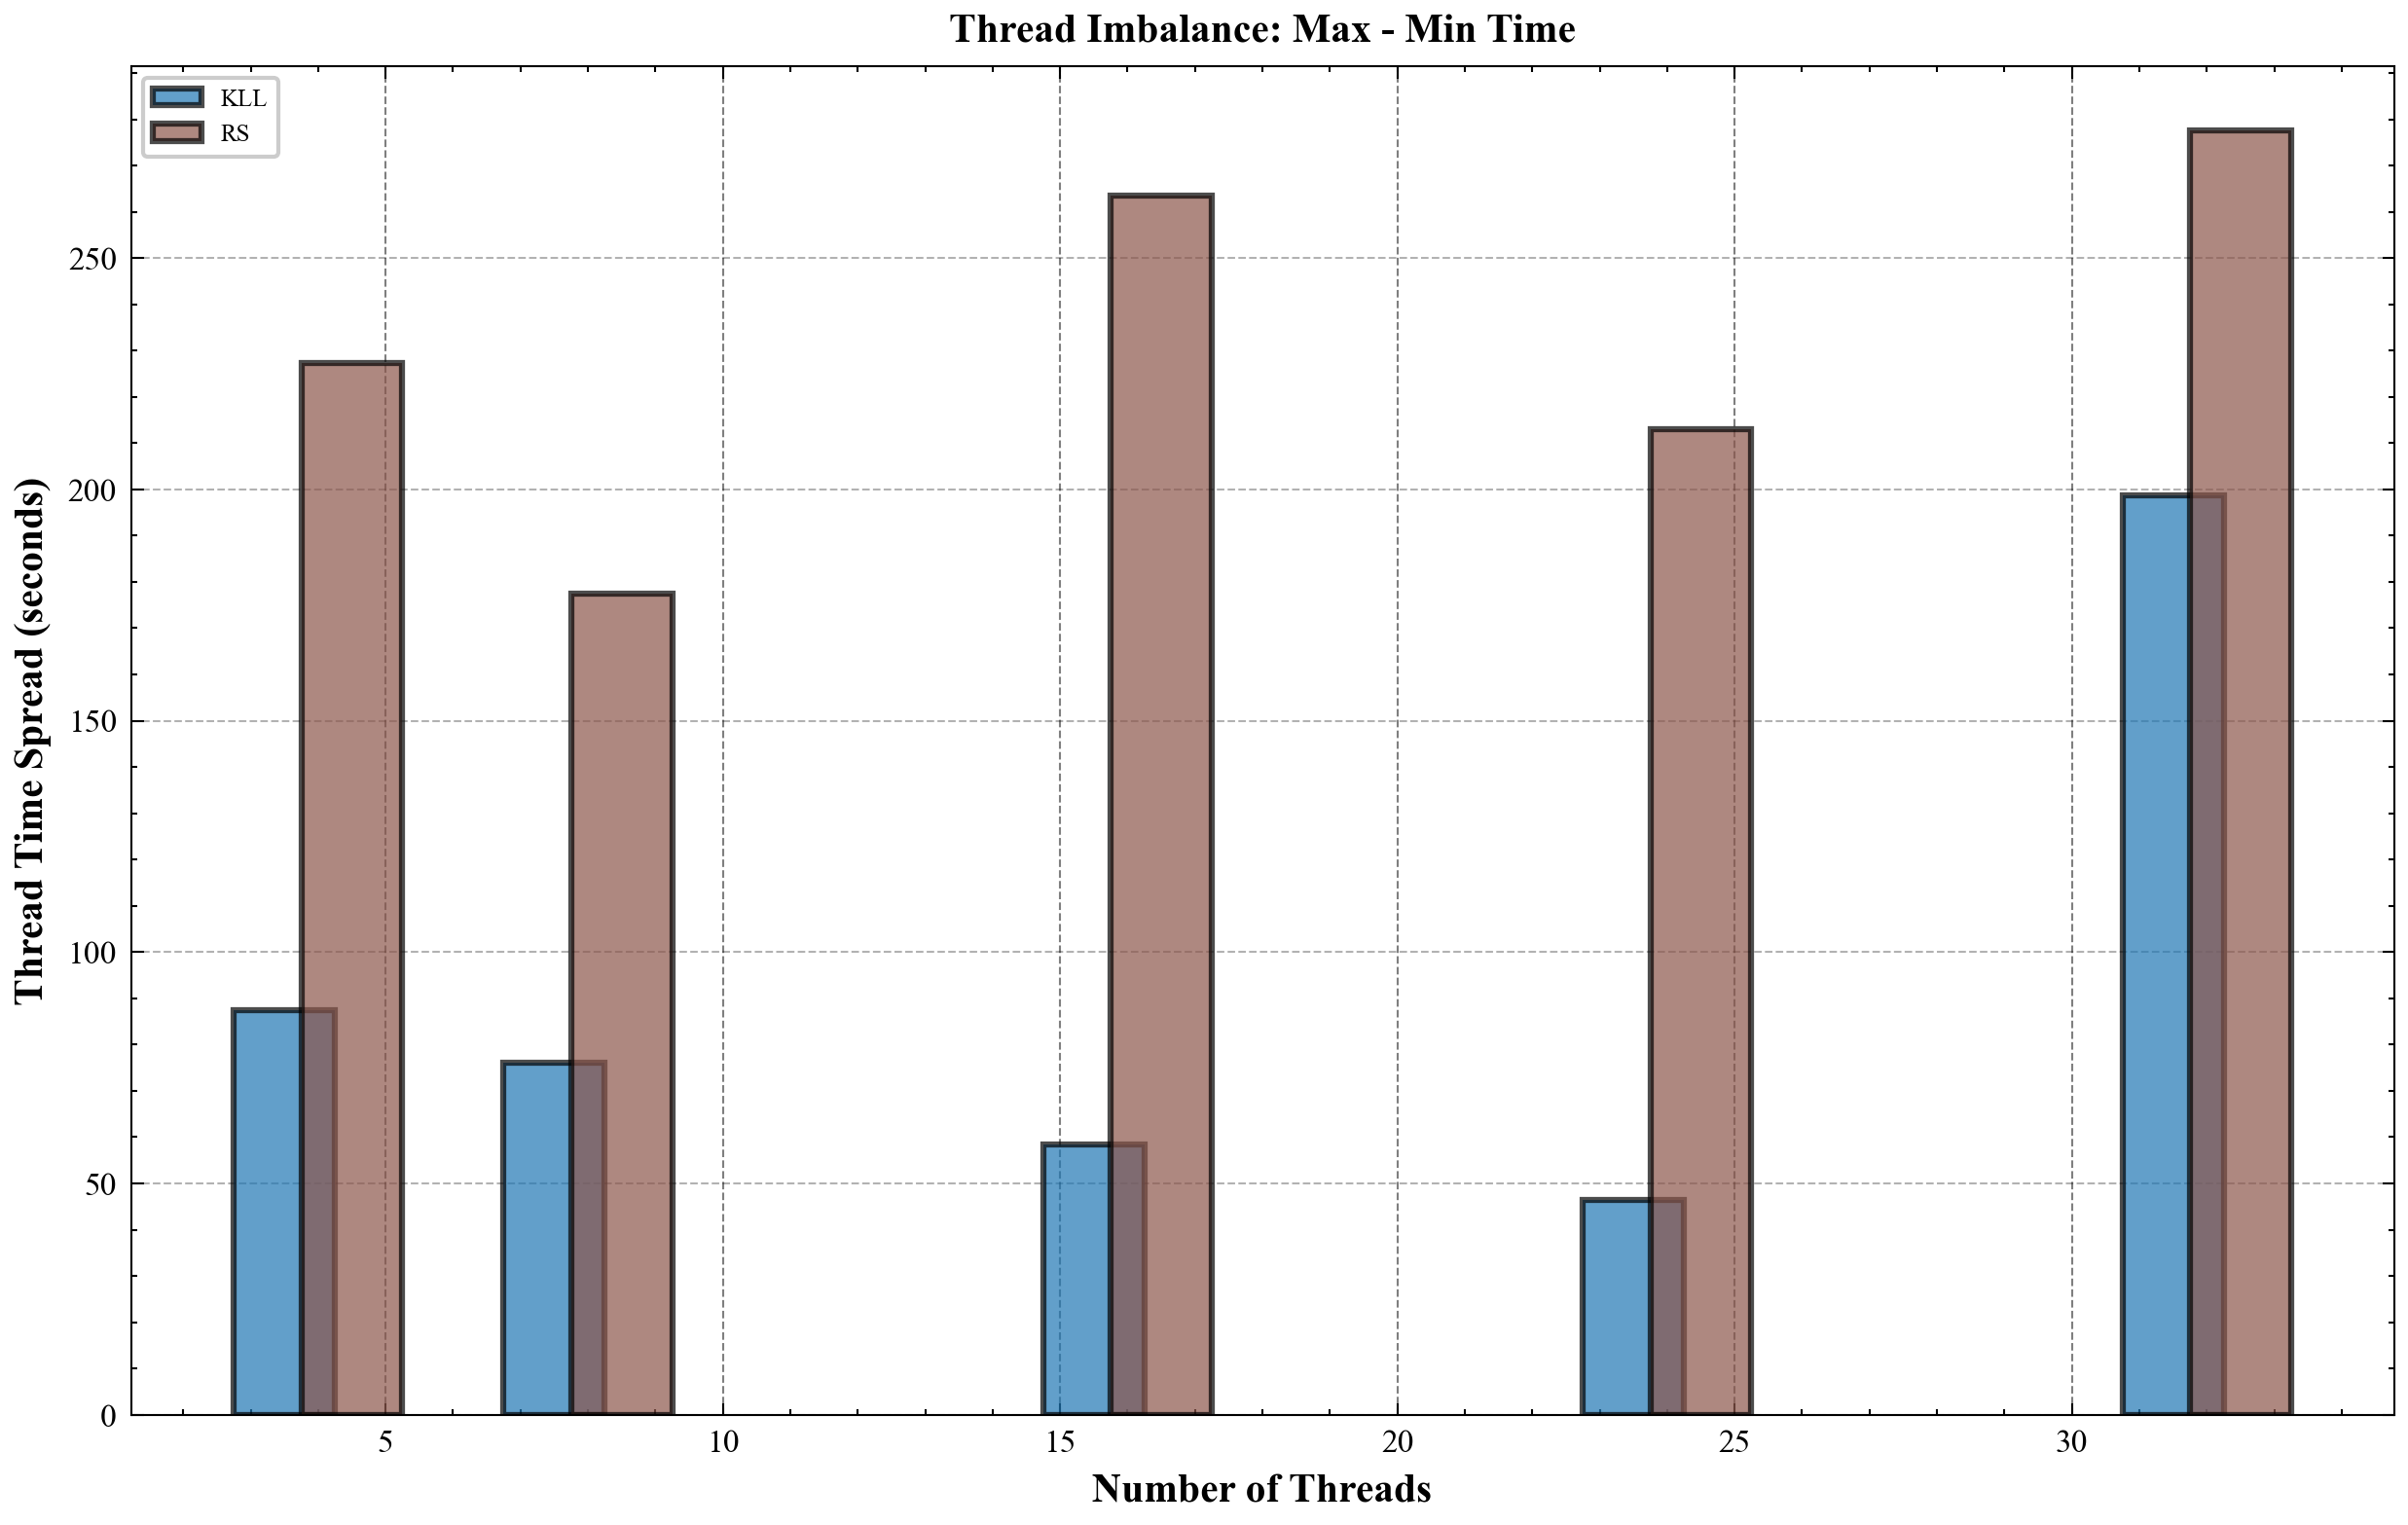

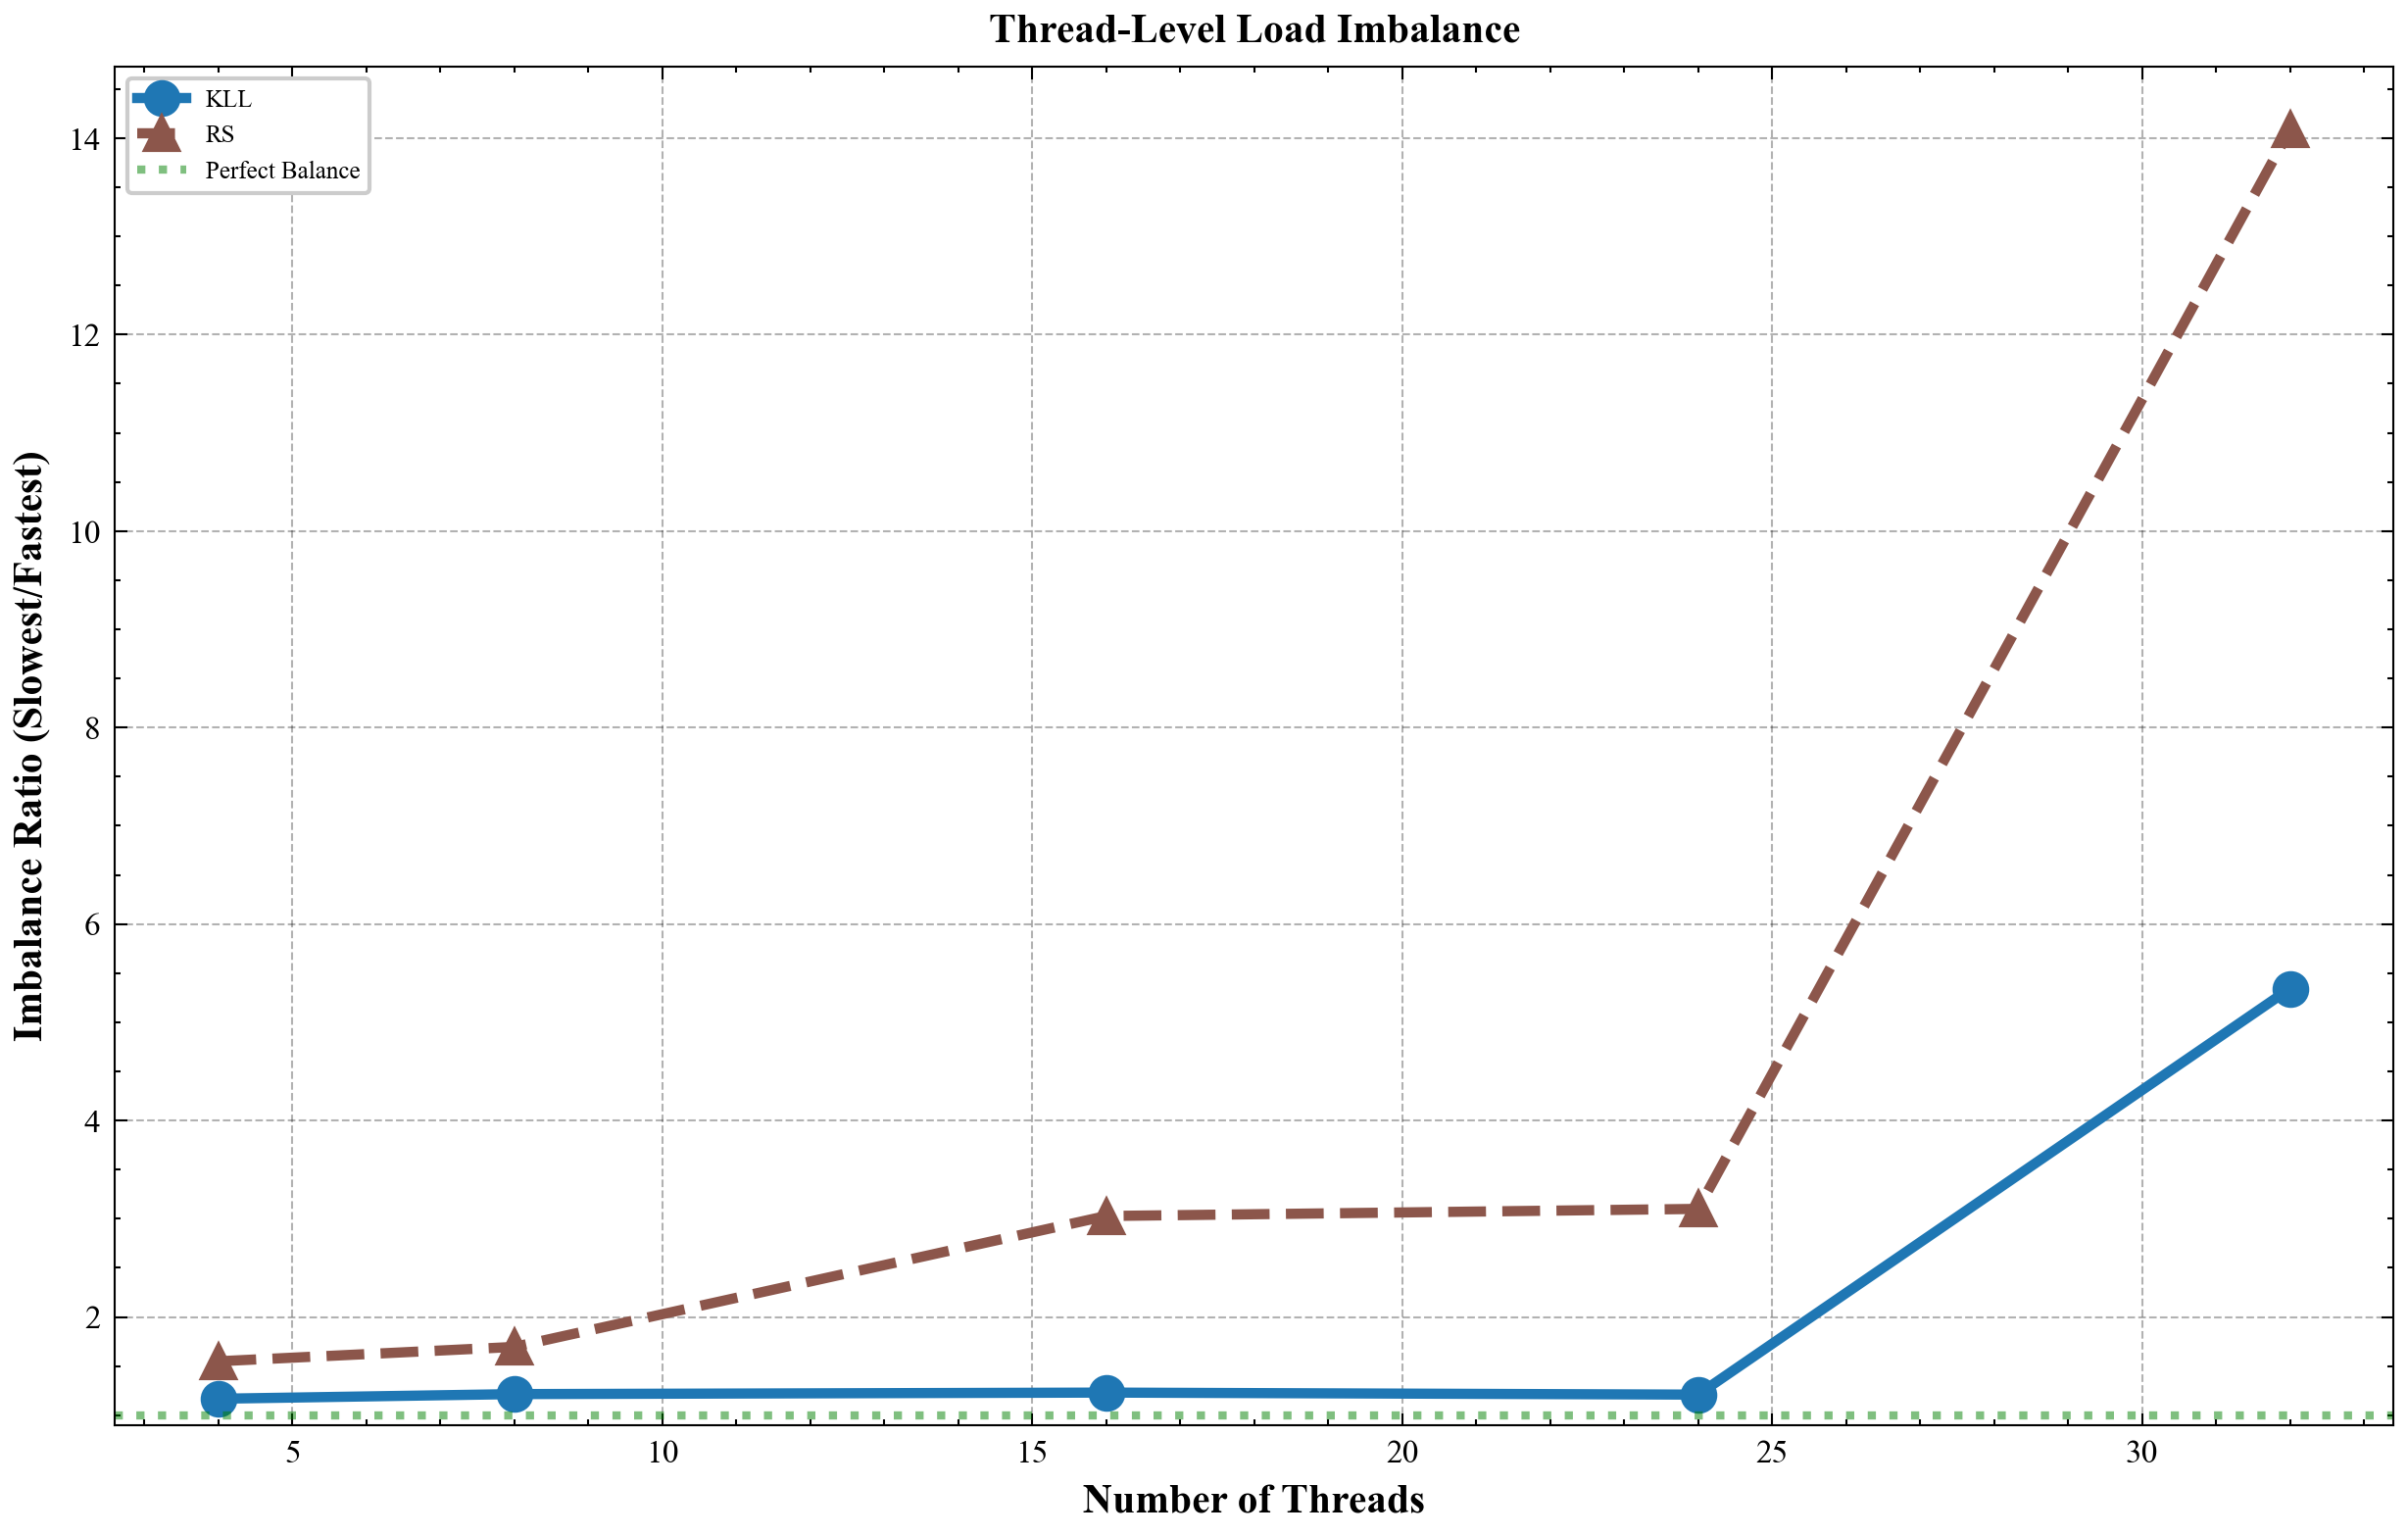


THREAD-LEVEL IMBALANCE STATISTICS
 Threads  KLL Fastest (s)  KLL Slowest (s)  KLL Spread (s)  KLL Ratio  RS Fastest (s)  RS Slowest (s)  RS Spread (s)  RS Ratio
       4            522.5            609.9            87.4      1.167           414.4           641.7          227.3     1.549
       8            354.6            430.7            76.0      1.214           255.5           433.1          177.5     1.695
      16            253.7            312.1            58.3      1.230           129.9           393.4          263.5     3.027
      24            222.5            269.0            46.5      1.209           101.5           314.6          213.1     3.100
      32             45.8            244.5           198.7      5.342            21.2           298.9          277.6    14.084

📊 Thread-Level Imbalance Analysis:

KLL Sketch:
  - Avg thread spread: 93.4s
  - Avg imbalance ratio: 2.033x
  - Worst case: 5.342x at 32 threads

Reservoir Sampling:
  - Avg thread spread: 231.8s
  - A

In [12]:
# Visualize thread-level imbalance: KLL vs RS
df_exp1_threads_sorted = df_exp1_threads.sort_values('threads')
df_exp4_threads_sorted = df_exp4_threads.sort_values('threads')
threads = df_exp1_threads_sorted['threads'].values

# Plot 1: Min/Max/Avg thread times for KLL
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(threads, df_exp1_threads_sorted['max_thread_time']/1000, 'o-', lw=2.5, markersize=8,
         color='#d62728', label='Slowest Thread')
ax1.plot(threads, df_exp1_threads_sorted['avg_thread_time']/1000, 's-', lw=2.5, markersize=8,
         color='#1f77b4', label='Average Thread')
ax1.plot(threads, df_exp1_threads_sorted['min_thread_time']/1000, '^-', lw=2.5, markersize=8,
         color='#2ca02c', label='Fastest Thread')
ax1.fill_between(threads, df_exp1_threads_sorted['min_thread_time']/1000, 
                  df_exp1_threads_sorted['max_thread_time']/1000, alpha=0.2, color='#1f77b4')
ax1.set_xlabel('Number of Threads', fontweight='bold')
ax1.set_ylabel('Merge Time (seconds)', fontweight='bold')
ax1.set_title('KLL: Thread-Level Merge Times - LineItem', fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.set_ylim(bottom=0)
plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp4_kll_thread_times.png'), dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Min/Max/Avg thread times for RS
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(threads, df_exp4_threads_sorted['max_thread_time']/1000, 'o-', lw=2.5, markersize=8,
         color='#d62728', label='Slowest Thread')
ax2.plot(threads, df_exp4_threads_sorted['avg_thread_time']/1000, 's-', lw=2.5, markersize=8,
         color='#8c564b', label='Average Thread')
ax2.plot(threads, df_exp4_threads_sorted['min_thread_time']/1000, '^-', lw=2.5, markersize=8,
         color='#2ca02c', label='Fastest Thread')
ax2.fill_between(threads, df_exp4_threads_sorted['min_thread_time']/1000, 
                  df_exp4_threads_sorted['max_thread_time']/1000, alpha=0.2, color='#8c564b')
ax2.set_xlabel('Number of Threads', fontweight='bold')
ax2.set_ylabel('Merge Time (seconds)', fontweight='bold')
ax2.set_title('Reservoir Sampling: Thread-Level Merge Times - LineItem', fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.set_ylim(bottom=0)
plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp4_rs_thread_times.png'), dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: Imbalance spread comparison (Max - Min)
fig3, ax3 = plt.subplots(figsize=(10, 6))
ax3.bar(threads - 0.5, df_exp1_threads_sorted['imbalance_spread']/1000, width=1.5, 
        color='#1f77b4', alpha=0.7, label='KLL', edgecolor='black', linewidth=1.5)
ax3.bar(threads + 0.5, df_exp4_threads_sorted['imbalance_spread']/1000, width=1.5,
        color='#8c564b', alpha=0.7, label='RS', edgecolor='black', linewidth=1.5)
ax3.set_xlabel('Number of Threads', fontweight='bold')
ax3.set_ylabel('Thread Time Spread (seconds)', fontweight='bold')
ax3.set_title('Thread Imbalance: Max - Min Time', fontweight='bold')
ax3.legend(loc='best')
ax3.grid(True, linestyle='--', alpha=0.3, axis='y')
ax3.set_ylim(bottom=0)
plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp4_thread_imbalance_spread.png'), dpi=300, bbox_inches='tight')
plt.show()

# Plot 4: Imbalance ratio comparison (Max / Min)
fig4, ax4 = plt.subplots(figsize=(10, 6))
ax4.plot(threads, df_exp1_threads_sorted['imbalance_ratio'], 'o-', lw=2.5, markersize=8,
         color='#1f77b4', label='KLL')
ax4.plot(threads, df_exp4_threads_sorted['imbalance_ratio'], '^--', lw=2.5, markersize=8,
         color='#8c564b', label='RS')
ax4.axhline(y=1.0, color='green', linestyle=':', lw=2, alpha=0.5, label='Perfect Balance')
ax4.set_xlabel('Number of Threads', fontweight='bold')
ax4.set_ylabel('Imbalance Ratio (Slowest/Fastest)', fontweight='bold')
ax4.set_title('Thread-Level Load Imbalance', fontweight='bold')
ax4.legend(loc='best')
ax4.grid(True, linestyle='--', alpha=0.3)
ax4.set_ylim(bottom=0.9)
plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp4_thread_imbalance_ratio.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print detailed statistics
print("\n" + "="*100)
print("THREAD-LEVEL IMBALANCE STATISTICS")
print("="*100)
imbalance_stats = pd.DataFrame({
    'Threads': threads,
    'KLL Fastest (s)': (df_exp1_threads_sorted['min_thread_time']/1000).round(1).values,
    'KLL Slowest (s)': (df_exp1_threads_sorted['max_thread_time']/1000).round(1).values,
    'KLL Spread (s)': (df_exp1_threads_sorted['imbalance_spread']/1000).round(1).values,
    'KLL Ratio': df_exp1_threads_sorted['imbalance_ratio'].round(3).values,
    'RS Fastest (s)': (df_exp4_threads_sorted['min_thread_time']/1000).round(1).values,
    'RS Slowest (s)': (df_exp4_threads_sorted['max_thread_time']/1000).round(1).values,
    'RS Spread (s)': (df_exp4_threads_sorted['imbalance_spread']/1000).round(1).values,
    'RS Ratio': df_exp4_threads_sorted['imbalance_ratio'].round(3).values
})
print(imbalance_stats.to_string(index=False))
print("="*100)

print(f"\n📊 Thread-Level Imbalance Analysis:")
print(f"\nKLL Sketch:")
print(f"  - Avg thread spread: {df_exp1_threads_sorted['imbalance_spread'].mean()/1000:.1f}s")
print(f"  - Avg imbalance ratio: {df_exp1_threads_sorted['imbalance_ratio'].mean():.3f}x")
print(f"  - Worst case: {df_exp1_threads_sorted['imbalance_ratio'].max():.3f}x at {threads[df_exp1_threads_sorted['imbalance_ratio'].argmax()]:.0f} threads")

print(f"\nReservoir Sampling:")
print(f"  - Avg thread spread: {df_exp4_threads_sorted['imbalance_spread'].mean()/1000:.1f}s")
print(f"  - Avg imbalance ratio: {df_exp4_threads_sorted['imbalance_ratio'].mean():.3f}x")
print(f"  - Worst case: {df_exp4_threads_sorted['imbalance_ratio'].max():.3f}x at {threads[df_exp4_threads_sorted['imbalance_ratio'].argmax()]:.0f} threads")

print(f"\nComparison:")
spread_increase = (df_exp4_threads_sorted['imbalance_spread'].mean() - df_exp1_threads_sorted['imbalance_spread'].mean()) / df_exp1_threads_sorted['imbalance_spread'].mean() * 100
print(f"  - RS has {spread_increase:.1f}% more thread time spread than KLL")
print(f"  - This causes idle time as fast threads wait for slow threads to finish")
print(f"  - On skewed LineItem data, RS creates significantly more thread imbalance than on uniform GenSort")